In [1]:
import json
import re
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter,FuncFormatter



## Paths and Metadata

In [2]:
metadata = {
    "000": {"label": "Baseline", "type": "baseline", "lora_conf": None},
    "001": {"label": "L0", "type": "standard", "lora_conf": None},
    # L0 Experiments (002*)
    "002": {
        "label": "L0",
        "type": "lora",
        "lora_conf": {
            "0020": {"lora_rank": 8},
            "0021": {"lora_rank": 16},
            "0022": {"lora_rank": 32},
            "0023": {"lora_rank": 64},
            "0024": {"lora_rank": 128},
            "0025": {"lora_rank": 256},
            "0026": {"lora_rank": 512},
            "0027": {"lora_rank": 96},
        },
    },
    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard", "lora_conf": None},
    "0031": {"label": "L1", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard", "lora_conf": None},
    "0041": {"label": "L2", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard", "lora_conf": None},
    "0051": {"label": "L3", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard", "lora_conf": None},
    "0061": {"label": "L4", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard", "lora_conf": None},
    "0071": {"label": "L5", "type": "lora", "lora_conf": {"lora_rank": 64}},
    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard", "lora_conf": None},
    "0081": {"label": "L6", "type": "lora", "lora_conf": {"lora_rank": 64}},
    "*-d": "Experiemnts with different dropouts",
}

datasets = ["gigaspeech", "spgispeech_2", "voxpopuli"]

accepted_exps_for_data_scaling = [
    "000",
    "001",
    "0023",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
]

In [3]:
def process_wer_results(filtered_paths, accepted_set):
    """
    Parses experiment paths to extract metadata and WER metrics.
    """
    all_wers_w_fraction = []
    baseline_ids = {"000", "001"}

    for p in filtered_paths:
        path_parts = p.parts
        path_str = str(p)
        
        # 1. Extract IDs and Basic Metadata
        exp_id = next((part for part in path_parts if part in accepted_set), None)
        # Using .parts is safer than split("/") for cross-platform compatibility
        dataset_name = path_parts[2] if len(path_parts) > 2 else "unknown"

        # 2. Regex Extraction
        fraction = None
        subset = None
        seed = None
        
        core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
        seed_match = re.search(r"seed_(\d+)", path_str)
        
        if seed_match:
            seed = seed_match.group(1)
            
        if core_match:
            fraction = float(core_match.group(1)) 
            subset = int(core_match.group(2))
        
        # 3. Load JSON and Extract WER
        try:
            with p.open() as f:
                loaded_results = json.load(f)
        except (FileNotFoundError, json.JSONDecodeError):
            continue # Skip files that can't be read

        wer = None
        wer_accent = None
        metrics = loaded_results.get("metrics", {})

        if str(p)=="../outputs/gigaspeech/005/0051/data_scaling/data_scaling_frac_1.0_subset_0/results.json":
            print(p)

        try:
            wer = metrics.get("wer") 
            if wer is None:
                if dataset_name == "voxpopuli":
                    wer = metrics.get("voxpopuli-en", {}).get("wer")
                    wer_accent = metrics.get("voxpopuli-en-accented", {}).get("wer")
                else:
                    lookup = "speechcolab-gigaspeech-m" if dataset_name == "gigaspeech" else dataset_name
                    wer = metrics.get(lookup, {}).get("wer")
                    dataset_name =="gigaspeech"
        except (TypeError, KeyError, AttributeError) as e:
            print(p)
            print(e)

        is_old = "_old" in path_str
        training_regime = "data_frac_steps" if is_old else "full_dataset_steps"
            
        is_half_steps = "half" in path_str
        training_steps = "half" if is_half_steps else "full_steps"

        is_dropout_exp = "-d" in path_str
        exp_type = "dropout" if is_dropout_exp else "normal_train_conf"
        # 4. Compile Dictionary
        res_w_metadata = {
            "experiment_id": exp_id,
            "dataset": dataset_name,
            "fraction": fraction,
            "subset": subset,
            "seed": seed,
            "wer": wer*100,
            "wer_accent": wer_accent,
            "training_regime": training_regime,
            "training_steps": training_steps,
            "exp_type": exp_type,
            "result_path": p
        }
        all_wers_w_fraction.append(res_w_metadata)
        
    return all_wers_w_fraction

In [4]:
def process_train_logs(log_paths, all_params=816967680):
    results_list = []

    # Pattern 1: Original (with || separators)
    # Pattern 2: New (Trainable params: 69906432 / 816967680 (8.56%))
    pattern_new = r"Trainable params:\s*([\d,]+)\s*/\s*([\d,]+)\s*\(([\d.]+)%\)"
    pattern_old = r"trainable params:\s*([\d,]+)\s*\|\|\s*all params:\s*([\d,]+)\s*\|\|\s*trainable%:\s*([\d.]+)"

    pattern_run_name = r'.*/(\d{3,4})'
    for log in log_paths:
        path_obj = Path(log)
        parts = path_obj.parts
        # run_name = parts[-3] if len(parts) >= 3 else "unknown"
        match = re.search(pattern_run_name, str(log))
        run_name = match.group(1)
        stats = {
            "experiment_id": run_name,
            "trainable_params": 0,
            "all_params": all_params, # Default fallback
            "trainable_pct": 0.0,
            "path": str(log)
        }
        
        try:
            with path_obj.open("r") as f:
                for line in f:
                    # Check for New Format
                    match_new = re.search(pattern_new, line, re.IGNORECASE)
                    if match_new:
                        stats["trainable_params"] = int(match_new.group(1).replace(",", ""))
                        stats["all_params"] = int(match_new.group(2).replace(",", ""))
                        stats["trainable_pct"] = float(match_new.group(3))
                        break
                    
                    # Check for Old Format
                    match_old = re.search(pattern_old, line, re.IGNORECASE)
                    if match_old:
                        stats["trainable_params"] = int(match_old.group(1).replace(",", ""))
                        stats["all_params"] = int(match_old.group(2).replace(",", ""))
                        stats["trainable_pct"] = float(match_old.group(3))
                        break
        except (FileNotFoundError, IOError):
            continue
            
        results_list.append(stats)

    df = pd.DataFrame(results_list)
    
    if not df.empty:
        df = df.rename(columns={
            "trainable_params": "Trainable Parameters",
            "all_params": "All Parameters",
            "trainable_pct": "Trainable %"
        })
    
    return df

In [5]:
def aggregate_wer_stats(df):
    # Define Median Absolute Deviation (MAD)
    mad_func = lambda x: (x - x.median()).abs().median()

    # Group by the core identifiers
    # Use tuples in .agg() to extract the 'first' instance of metadata
    stats = (
        df.groupby(["dataset", "experiment_id"])
        .agg(
            lora_rank=("lora_rank", "first"),
            mean=("wer", "mean"),
            median=("wer", "median"),
            std=("wer", "std"),
            mad=("wer", mad_func),
        )
        .reset_index()
    )

    # Move metadata columns to the front if desired
    cols = [
        "experiment_id",
        "lora_rank",
        "dataset",
        "mean",
        "median",
        "std",
        "mad",
    ]
    return stats[cols]

In [6]:
def filter_paths(all_res_paths, accepted_set, exclude_set):
    """
    Performs the actual path filtering based on provided sets.
    """
    return [
        path for path in all_res_paths 
        if any(part in accepted_set for part in path.parts) 
        and not any(word in str(path) for word in exclude_set)
    ]

## All Paths

In [7]:
results_dir = "../outputs/"
all_res_paths = list(Path(results_dir).rglob("results.json"))

all_train_logs = list(Path(results_dir).glob("**/*.log"))

## Data Collection

In [8]:
accepted_exps= {
    "000",
    "001",
    "0020",
    "0021",
    "0022",
    "0023",
    "0024",
    "0025",
    "0026",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
}
baselines_id = ["000", "001"]
all_res = process_wer_results(all_res_paths,accepted_exps)
df = pd.DataFrame(all_res)
df["source"] = "BU"
df_from_rad_1 = pd.read_csv("/mnt/asr-data-scaling/outputs/voxpopuli_from_rad1.csv",dtype={'experiment_id': str})
df_from_rad_1["source"] = "Rad1"
df_from_rad_2 = pd.read_csv("/mnt/asr-data-scaling/outputs/voxpopuli_from_rad2.csv",dtype={'experiment_id': str})
df_from_rad_2["source"] = "Rad2"
df_from_rad_2["wer"] = df_from_rad_2["wer"]*100
if any(item not in df_from_rad_2.columns for item in ["training_regime","training_steps","exp_type"]):
    df_from_rad_2["training_regime"] = "data_frac_steps"
    df_from_rad_2["training_steps"] = "full_steps"
    df_from_rad_2["exp_type"] = "normal_train_conf"

df_main = pd.concat([df,df_from_rad_2,df_from_rad_1],ignore_index=True)
df_main

../outputs/gigaspeech/005/0051/data_scaling/data_scaling_frac_1.0_subset_0/results.json


,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source
0,0070,voxpopuli,1.0,0.0,None,5.875927,0.278698,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/007/0070/0070_frac_1.0_su...,BU
1,0071,voxpopuli,1.0,0.0,None,6.389606,0.210164,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/007/0071/0071_frac_1.0_su...,BU
2,0041,voxpopuli,1.0,0.0,None,7.398368,0.186027,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/0041_frac_1.0_su...,BU
3,0040,voxpopuli,1.0,0.0,None,7.691235,0.222483,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0040/0040_frac_1.0_su...,BU
4,0060,voxpopuli,1.0,0.0,None,6.261767,0.245355,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/006/0060/0060_frac_1.0_su...,BU
...,...,...,...,...,...,...,...,...,...,...,...,...
430,0041,voxpopuli,0.2,4.0,NaN,7.507612,0.189524,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1
431,0041,voxpopuli,0.1,2.0,NaN,7.619180,0.220612,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1
432,0041,voxpopuli,0.2,0.0,NaN,7.470423,0.190797,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1
433,0041,voxpopuli,0.1,1.0,NaN,7.572694,0.192562,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1


In [9]:
df_logs_main = process_train_logs(all_train_logs)
df_logs_main

,experiment_id,Trainable Parameters,All Parameters,Trainable %,path
0,0070,456182784,816967680,55.8400,../outputs/voxpopuli/007/0070/0070_frac_1.0_su...
1,0071,44279360,861247040,5.1413,../outputs/voxpopuli/007/0071/0071_frac_1.0_su...
2,0040,69906432,816967680,8.5600,../outputs/voxpopuli/004/0040/0040_frac_1.0_su...
3,0060,254647296,816967680,31.1700,../outputs/voxpopuli/006/0060/0060_frac_1.0_su...
4,0061,23832128,840799808,2.8345,../outputs/voxpopuli/006/0061/0061_frac_1.0_su...
...,...,...,...,...,...
305,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
306,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
307,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...
308,0051,6792768,823760448,0.8246,../outputs/spgispeech_2/005/0051/data_scaling_...


In [10]:
sns.set_style("whitegrid", {'axes.axisbelow': True})

## 1. LoRA Configuration Selection

This section provides the necessary results and visualisation for finding the best LoRA ranks for the next experiments. Here we targeted the L0 layer as the representative of layer-wise fine tuning and examined the effect of different ranks (8,16,32,64,128,512) on the model performance using different datasets. The results show that rank of 64 (on average) showing globally acceptable performance across all datasets. So for the next experiemnts with different layers setup, we will use rank = 64 for fine-tuning with LoRA

In [11]:
df_normal_train_conf = df_main[df_main["exp_type"]!="dropout"]

df_lora_conf = df_normal_train_conf[
    ~(df_normal_train_conf["seed"].isnull())
    | (df_normal_train_conf["experiment_id"].isin(baselines_id))
]
df_lora_conf

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source
6,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...,BU
7,000,voxpopuli,NaN,NaN,None,102.068661,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/repeat_inference/infe...,BU
8,0022,voxpopuli,1.0,0.0,123,7.800479,0.203139,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123_frac_1....,BU
9,0022,voxpopuli,1.0,0.0,123456,7.884155,0.206904,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123456_frac...,BU
10,0022,voxpopuli,1.0,0.0,12345,7.898101,0.201384,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_12345_frac_...,BU
...,...,...,...,...,...,...,...,...,...,...,...,...
272,0025,spgispeech_2,1.0,0.0,1234,7.059909,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_1234_fra...,BU
273,0025,spgispeech_2,1.0,0.0,42,7.462049,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_42_frac_...,BU
310,001,spgispeech_2,NaN,NaN,None,6.831164,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/001/001/results.json,BU
403,001,voxpopuli,1.0,0.0,NaN,8.637241,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/001/0010/0010_frac_1.0_su...,Rad1


In [12]:
df_log_lora_conf = df_logs_main[
    df_logs_main["experiment_id"].isin(df_lora_conf["experiment_id"].unique())
]
df_log_lora_conf.drop_duplicates(subset="experiment_id",inplace=True)

lora_confs = metadata["002"]["lora_conf"]
df_log_lora_conf["lora_rank"] = df_log_lora_conf["experiment_id"].apply(lambda x: lora_confs.get(x, {}).get("lora_rank", 0))
df_log_lora_conf

/tmp/ipykernel_114833/3635592585.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_log_lora_conf.drop_duplicates(subset="experiment_id",inplace=True)
/tmp/ipykernel_114833/3635592585.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_log_lora_conf["lora_rank"] = df_log_lora_conf["experiment_id"].apply(lambda x: lora_confs.get(x, {}).get("lora_rank", 0))


,experiment_id,Trainable Parameters,All Parameters,Trainable %,path,lora_rank
5,000,0,816967680,0.0000,../outputs/voxpopuli/000/inference_results/inf...,0
7,0022,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
12,0023,3384896,820352576,0.4126,../outputs/voxpopuli/002/0023/seed_123_frac_1....,64
17,0020,423112,817390792,0.0518,../outputs/voxpopuli/002/0020/seed_123_frac_1....,8
22,0021,846224,817813904,0.1035,../outputs/voxpopuli/002/0021/seed_123_frac_1....,16
27,0024,6769792,823737472,0.8218,../outputs/voxpopuli/002/0024/seed_123_frac_1....,128
32,0026,27079168,844046848,3.2083,../outputs/voxpopuli/002/0026/seed_123_frac_1....,512
37,0025,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
46,001,53109760,816967680,6.5000,../outputs/voxpopuli/001/001_s_frac_1.0_subset...,0


In [13]:
df_lora_conf_final = pd.merge(df_lora_conf,df_log_lora_conf,on="experiment_id",how="left")
df_lora_conf_final

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,Trainable Parameters,All Parameters,Trainable %,path,lora_rank
0,000,voxpopuli,NaN,NaN,None,102.068661,0.951458,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/inference_results/res...,BU,0,816967680,0.0000,../outputs/voxpopuli/000/inference_results/inf...,0
1,000,voxpopuli,NaN,NaN,None,102.068661,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/repeat_inference/infe...,BU,0,816967680,0.0000,../outputs/voxpopuli/000/inference_results/inf...,0
2,0022,voxpopuli,1.0,0.0,123,7.800479,0.203139,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123_frac_1....,BU,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
3,0022,voxpopuli,1.0,0.0,123456,7.884155,0.206904,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_123456_frac...,BU,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
4,0022,voxpopuli,1.0,0.0,12345,7.898101,0.201384,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/002/0022/seed_12345_frac_...,BU,1692448,818660128,0.2067,../outputs/voxpopuli/002/0022/seed_123_frac_1....,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,0025,spgispeech_2,1.0,0.0,1234,7.059909,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_1234_fra...,BU,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
115,0025,spgispeech_2,1.0,0.0,42,7.462049,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0025/seed_42_frac_...,BU,13539584,830507264,1.6303,../outputs/voxpopuli/002/0025/seed_123_frac_1....,256
116,001,spgispeech_2,NaN,NaN,None,6.831164,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/001/001/results.json,BU,53109760,816967680,6.5000,../outputs/voxpopuli/001/001_s_frac_1.0_subset...,0
117,001,voxpopuli,1.0,0.0,NaN,8.637241,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/001/0010/0010_frac_1.0_su...,Rad1,53109760,816967680,6.5000,../outputs/voxpopuli/001/001_s_frac_1.0_subset...,0


In [14]:
df_lora_conf_agg = aggregate_wer_stats(df_lora_conf_final)
df_lora_conf_agg

,experiment_id,lora_rank,dataset,mean,median,std,mad
0,000,0,gigaspeech,14.953090,14.953090,NaN,0.000000
1,001,0,gigaspeech,13.523135,13.523135,NaN,0.000000
2,0020,8,gigaspeech,19.441619,19.098648,2.330859,2.390443
3,0021,16,gigaspeech,16.474610,15.180020,3.615240,0.868329
4,0022,32,gigaspeech,14.377392,14.324326,0.897006,0.203890
5,0023,64,gigaspeech,13.806946,13.955937,0.571061,0.446180
6,0024,128,gigaspeech,13.854264,14.182867,0.880847,0.493003
7,0025,256,gigaspeech,14.170331,14.260162,0.646226,0.608697
8,0026,512,gigaspeech,16.098343,15.763696,0.605636,0.159297
9,000,0,spgispeech_2,11.561548,11.561548,NaN,0.000000


In [15]:
def plot_wer_lora_conf(df, dataset_name, metric_type='mean', color='#E67E22', padding_rate=.15, log_scale=True):
    # 1. Prepare LoRA Data
    df_copy = df.copy()
    metric_cols = ['mean', 'std', 'median', 'mad', 'lora_rank']
    df_copy[metric_cols] = df_copy[metric_cols].apply(pd.to_numeric, errors='coerce')

    # Filter for specific dataset and LoRA ranks > 0
    subset = df_copy[(df_copy['dataset'] == dataset_name) & (df_copy['lora_rank'] > 0)].copy()
    subset = subset.sort_values('lora_rank').dropna(subset=['lora_rank', 'mean'])
    
    # Force X-axis to be categorical strings to match the "Layers" plot style
    subset['lora_rank_str'] = subset['lora_rank'].astype(int).astype(str)
    
    if metric_type == 'mean':
        y_col, err_col = 'mean', 'std'
        metric_label = "Mean"
    else:
        y_col, err_col = 'median', 'mad'
        metric_label = "Median"

    # 2. Setup Figure & Style
    plt.figure(figsize=(6, 5))
    ax = plt.gca()

    # 3. Plot LoRA results using Seaborn logic
    # Line and Markers
    sns.lineplot(
        data=subset, x='lora_rank_str', y=y_col, 
        marker='o', markersize=8, linewidth=2, color=color, 
        label=f'LoRA ({metric_label} WER)', ax=ax, zorder=3
    )
    
    # Error Shading (Manual fill to match the Deeper Layers look)
    plt.fill_between(
        subset['lora_rank_str'], 
        subset[y_col] - subset[err_col], 
        subset[y_col] + subset[err_col], 
        color=color, alpha=0.2, zorder=2
    )

    # 4. Baselines & Outlier Logic (The "Smart" Handling)
    base_data = df_copy[(df_copy['lora_rank'] == 0) & (df_copy['dataset'] == dataset_name)]
    base_val = base_data[base_data['experiment_id'].str.lower() == '000'][metric_type].mean()
    std_val = base_data[base_data['experiment_id'].str.lower() == '001'][metric_type].mean()

    # Determine Y-limits based on LoRA data only
    y_min, y_max = subset[y_col].min(), subset[y_col].max()

    if log_scale:
        ax.set_yscale('log')
        view_min, view_max = y_min / (1 + padding_rate), y_max * (1 + padding_rate)
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())
    else:
        view_min, view_max = y_min - (y_max * padding_rate), y_max + (y_max * padding_rate)
    
    ax.set_ylim(view_min, view_max)

    # Outlier Detection for Baselines
    baseline_info = []
    if pd.notna(base_val):
        if base_val <= view_max * 1.2:
            plt.axhline(y=base_val, color='red', linestyle='--', alpha=0.6, label=f'Base: {base_val:.2f}%', zorder=1)
        else:
            baseline_info.append(f"BASELINE: {base_val:.2f}%")

    if pd.notna(std_val):
        # Using the Blue color from the Deeper Layers plot for Standard FT
        if std_val <= view_max * 1.2:
            plt.axhline(y=std_val, color='black', linestyle=':', alpha=0.8, label=f'Full FT: {std_val:.2f}%', zorder=1)
        else:
            baseline_info.append(f"FULL FT: {std_val:.2f}%")

    # Add text box if values are off-chart
    if baseline_info:
        plt.text(0.5, 0.95, "  |  ".join(baseline_info), transform=ax.transAxes, 
                 fontsize=9, fontweight='bold', color='red', ha='center', va='top',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', boxstyle='round,pad=0.3'))

    # 5. Final Formatting
    plt.title(f"{dataset_name.upper()} - LoRA Scaling", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("LoRA Rank ($r$)", fontsize=11, fontweight='bold')
    plt.ylabel("WER (%)", fontsize=11, fontweight='bold')
    # plt.grid(True, which="both", axis="y", linestyle='--', alpha=0.4)
    
    plt.legend(loc='best', fontsize='small', frameon=True)
    plt.tight_layout()
    plt.show()

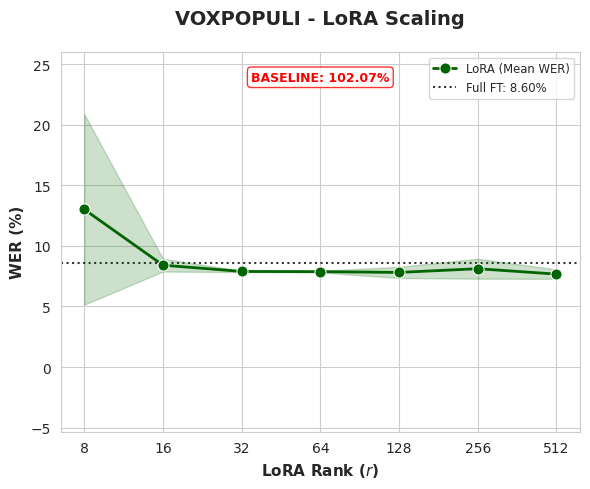

In [16]:
dataset_name = "voxpopuli"
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name=dataset_name,
    color="darkgreen",
    padding_rate=1,
    log_scale=False,
    metric_type="mean",
)

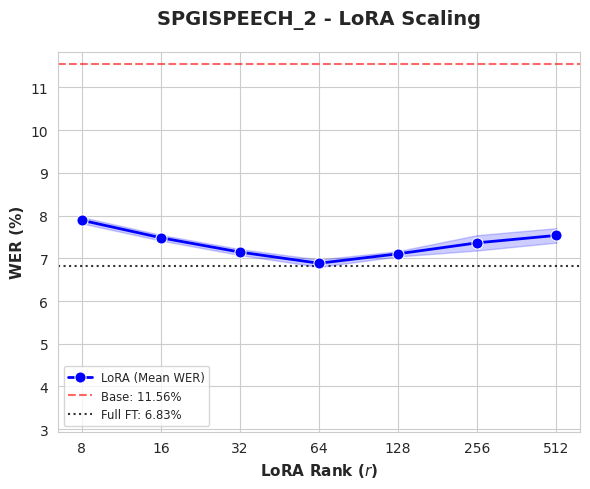

In [17]:
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name="spgispeech_2",
    padding_rate=0.5,
    color="blue",
    log_scale=False,
    metric_type="mean",
)

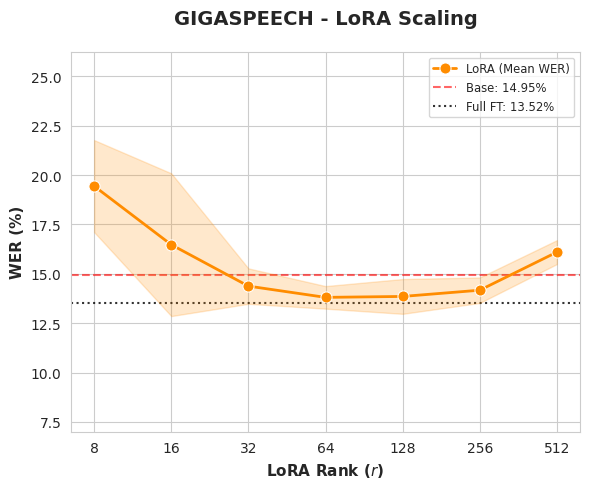

In [18]:
plot_wer_lora_conf(
    df=df_lora_conf_agg,
    dataset_name="gigaspeech",
    color="darkorange",
    padding_rate=0.35,
    log_scale=False,
    metric_type="mean",
)

###

## 2. Deeper Layers Training Results

In [19]:
accepted_experiment_ids = [
    "000",
    "001",
    "0023",
    "0030",
    "0031",
    "0040",
    "0041",
    "0050",
    "0051",
    "0060",
    "0061",
    "0070",
    "0071",
    "0080",
    "0081",
]
mask = (df_main["experiment_id"].isin(accepted_experiment_ids)) & \
       ((df_main["fraction"] == 1.0) | (df_main["fraction"].isna()))
df_deeper_ls = df_main[mask]

df_deeper_ls = df_deeper_ls.sort_values("wer",ascending=True)
group_cols = ['experiment_id', 'dataset', 'fraction', 'subset']
df_deeper_ls_best = df_deeper_ls.drop_duplicates(subset= group_cols, keep="first").reset_index(drop=True)
df_deeper_ls_best.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source
34,000,spgispeech_2,NaN,NaN,None,11.561548,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/000/results.json,BU
35,0023,gigaspeech,1.0,0.0,42,13.033353,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/gigaspeech/002/0023/seed_42_frac_1....,BU
36,001,gigaspeech,NaN,NaN,None,13.523135,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/001/001/results.json,BU
37,000,gigaspeech,NaN,NaN,None,14.953090,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/000/inference_results/re...,BU
38,000,voxpopuli,NaN,NaN,None,102.068661,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/repeat_inference/infe...,BU


In [20]:
df_deeper_ls_logs = df_logs_main[
    df_logs_main["experiment_id"].isin(accepted_experiment_ids)
]
df_deeper_ls_logs = (
    df_deeper_ls_logs.drop_duplicates(subset="experiment_id")
    .drop("path", axis=1)
    .reset_index(drop=True)
)
df_deeper_ls_logs.tail()

,experiment_id,Trainable Parameters,All Parameters,Trainable %
8,0081,47664256,864631936,5.5127
9,0050,86701056,816967680,10.6100
10,0051,6792768,823760448,0.8246
11,001,53109760,816967680,6.5000
12,0041,5088832,822056512,0.6190


In [21]:
df_deeper_ls_final = pd.merge(
    df_deeper_ls_best, df_deeper_ls_logs, on="experiment_id", how="left"
)
df_deeper_ls_final["type"] = df_deeper_ls_final["experiment_id"].apply(
    lambda x: metadata.get(x, {}).get("type", "lora")
)
df_deeper_ls_final["label"] = df_deeper_ls_final[
    "experiment_id"
].apply(lambda x: metadata.get(x, {}).get("label", "L0"))
df_deeper_ls_final.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,Trainable Parameters,All Parameters,Trainable %,type,label
34,000,spgispeech_2,NaN,NaN,None,11.561548,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/000/results.json,BU,0,816967680,0.0000,baseline,Baseline
35,0023,gigaspeech,1.0,0.0,42,13.033353,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/gigaspeech/002/0023/seed_42_frac_1....,BU,3384896,820352576,0.4126,lora,L0
36,001,gigaspeech,NaN,NaN,None,13.523135,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/001/001/results.json,BU,53109760,816967680,6.5000,standard,L0
37,000,gigaspeech,NaN,NaN,None,14.953090,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/gigaspeech/000/inference_results/re...,BU,0,816967680,0.0000,baseline,Baseline
38,000,voxpopuli,NaN,NaN,None,102.068661,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/000/repeat_inference/infe...,BU,0,816967680,0.0000,baseline,Baseline


In [22]:
def plot_deeper_layers_comparison_optimized(df, title="WER Comparison: Standard vs LoRA Fine-Tuning", log_scale=True, padding_rate=0.05):
    """
    Refined version with unified fonts and grid settings.
    """
    baseline_row = df[df["type"].str.lower() == "baseline"]
    baseline_wer = None
    if not baseline_row.empty:
        val = baseline_row["wer"].iloc[0]
        baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
        
    plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
    def sort_key(label):
        label_str = str(label)
        if label_str.startswith("L"):
            try: return int(label_str[1:])
            except: return 999
        return 0
        
    unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
    exploded_df = plot_df.explode("wer")
    exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
    plt.figure(figsize=(6, 5))
    palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
    ax = sns.lineplot(
        data=exploded_df, 
        x="label", 
        y="wer", 
        hue="type", 
        marker="o", 
        palette=palette,
        linewidth=2,
        markersize=6,
        errorbar="sd"
    )
    
    all_exp_values = exploded_df["wer"].dropna()
    y_min, y_max = all_exp_values.min(), all_exp_values.max()

    if log_scale:
        plt.yscale('log')
        view_min, view_max = y_min / (1 + padding_rate), y_max * (1 + padding_rate)
        ax.yaxis.set_major_formatter(ScalarFormatter())
    else:
        view_min, view_max = y_min - (y_max * padding_rate), y_max + (y_max * padding_rate)
    
    plt.ylim(view_min, view_max)

    # Baseline Handling
    if baseline_wer is not None:
        if baseline_wer <= view_max * 1.5:
            plt.axhline(y=baseline_wer, color="red", linestyle="--", alpha=0.6, label=f"Baseline: {baseline_wer:.2f}")
        else:
            plt.text(0.5, 0.96, f"BASELINE: {baseline_wer:.2f}", 
                     transform=ax.transAxes, color="red", fontweight="bold", 
                     ha="center", va="top", bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

    # Styling Unification
    plt.title(title, fontsize=14, fontweight="bold", pad=20)
    plt.ylabel("WER (%)", fontsize=11, fontweight='bold')
    plt.xlabel("Layers Involved", fontsize=11, fontweight='bold')
    
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["Full FT" if l == "standard" else "LoRA (r=64)" if l == "lora" else l for l in labels]
    
    plt.legend(handles, new_labels, loc='best', fontsize=11, frameon=True)
    plt.tight_layout()
    plt.show()

,label,type,Trainable %,fraction,dataset,wer
0,L6,standard,62.4000,1.0,spgispeech_2,4.173933
1,L5,standard,55.8400,1.0,spgispeech_2,4.193232
2,L4,standard,31.1700,1.0,spgispeech_2,4.461847
3,L5,lora,5.1413,1.0,spgispeech_2,4.862135
4,L6,lora,5.5127,1.0,spgispeech_2,4.872034
5,L4,lora,2.8345,1.0,spgispeech_2,5.201750
6,L3,standard,10.6100,1.0,spgispeech_2,5.681155
7,L2,standard,8.5600,1.0,spgispeech_2,5.828068
14,L3,lora,0.8246,1.0,spgispeech_2,6.686389
15,L2,lora,0.6190,1.0,spgispeech_2,6.716948


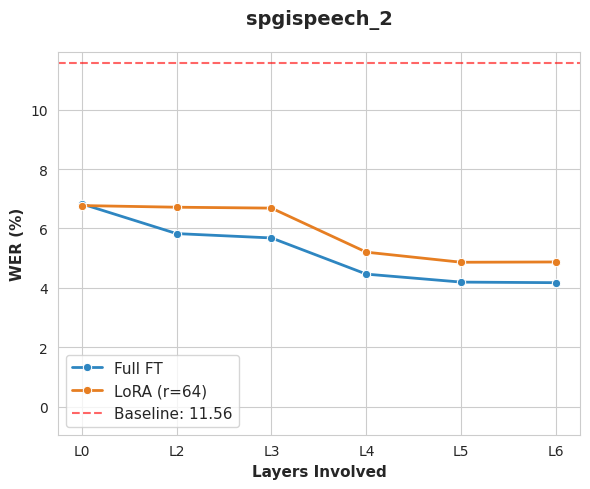

In [23]:
dataset_name = "spgispeech_2"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
display(df_2_plot[["label","type","Trainable %","fraction","dataset","wer"]])
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.75,log_scale=False,title=title)

,label,type,Trainable %,fraction,dataset,wer
37,Baseline,baseline,0.0000,NaN,gigaspeech,14.953090
35,L0,lora,0.4126,1.0,gigaspeech,13.033353
36,L0,standard,6.5000,NaN,gigaspeech,13.523135
30,L2,standard,8.5600,1.0,gigaspeech,10.747209
33,L2,lora,0.6190,1.0,gigaspeech,11.092558
31,L3,lora,0.8246,1.0,gigaspeech,10.903285
32,L3,standard,10.6100,1.0,gigaspeech,10.975625
26,L4,lora,2.8345,1.0,gigaspeech,9.606861
27,L4,standard,31.1700,1.0,gigaspeech,9.741880
25,L5,lora,5.1413,1.0,gigaspeech,9.463915


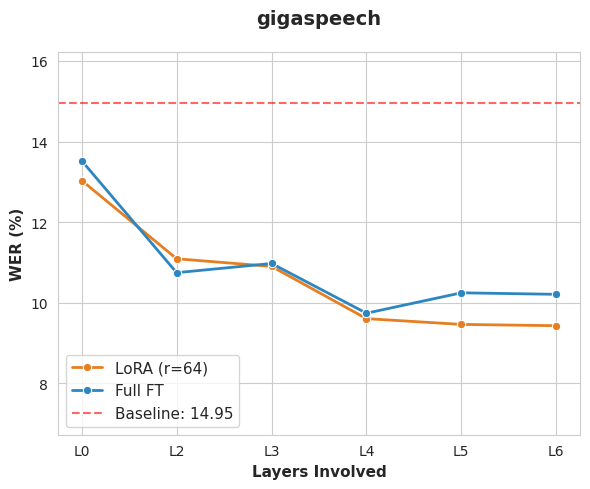

In [24]:
dataset_name = "gigaspeech"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
display(df_2_plot[["label","type","Trainable %","fraction","dataset","wer"]].sort_values("label"))
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.2,log_scale=False,title=title)

,label,type,Trainable %,fraction,dataset,wer
38,Baseline,baseline,0.0000,NaN,voxpopuli,102.068661
22,L0,lora,0.4126,1.0,voxpopuli,7.767938
23,L0,standard,6.5000,1.0,voxpopuli,8.465240
19,L2,standard,8.5600,1.0,voxpopuli,7.156637
21,L2,lora,0.6190,1.0,voxpopuli,7.398368
17,L3,standard,10.6100,1.0,voxpopuli,6.821932
20,L3,lora,0.8246,1.0,voxpopuli,7.300746
10,L4,standard,31.1700,1.0,voxpopuli,6.261767
13,L4,lora,2.8345,1.0,voxpopuli,6.603445
8,L5,standard,55.8400,1.0,voxpopuli,5.875927


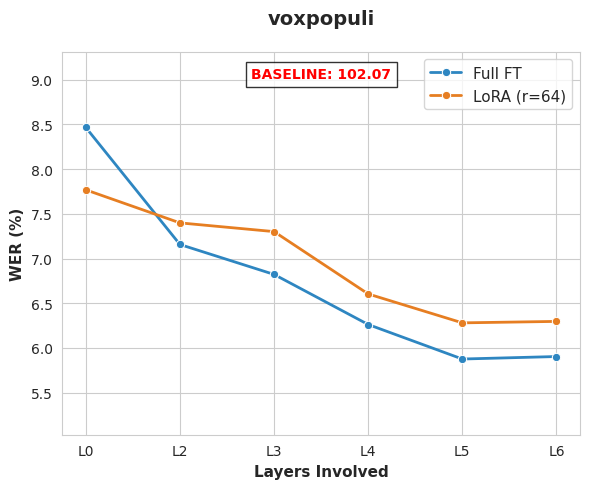

In [25]:
dataset_name = "voxpopuli"
title=dataset_name
df_2_plot = df_deeper_ls_final[df_deeper_ls_final["dataset"]==dataset_name]
display(df_2_plot[["label","type","Trainable %","fraction","dataset","wer"]].sort_values("label"))
plot_deeper_layers_comparison_optimized(df_2_plot,padding_rate=.1,log_scale=False,title=title)

### Optimising 0070 with layer-specific dropout

In [26]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import ScalarFormatter
# import matplotlib.lines as mlines
# from matplotlib.ticker import FormatStrFormatter

# import seaborn as sns
# from pathlib import Path
# import re
# import json

In [27]:
# # 1. Get all json paths
# all_jsons_paths = list(Path("../outputs/gigaspeech/007").glob("**/results.json"))
# # 2. Load the jsons into memory
# all_jsons = [json.load(open(j)) for j in all_jsons_paths]
# # 3. Update each dictionary with the new key (using a fast loop instead of list comprehension)
# for item in all_jsons:
#     item['exp_id'] = item['model_path'].split("/")[-2]
#     try:
#         item["wer"] = item["metrics"]["speechcolab-gigaspeech-m"]["wer"]
#     except KeyError:
#         item["wer"] = item["metrics"]["wer"]
# df_007 = pd.DataFrame(all_jsons)
# df_007 = df_007.groupby("exp_id").agg({"wer": "mean"}).reset_index()
# df_007


In [28]:
# hyperparameters_list = [
#     {"exp_id": "0070",   "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"base"},
#     {"exp_id": "00701-d", "dropout": 0.1, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00702-d", "dropout": 0.5, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00703-d", "dropout": 0.1, "attention_dropout": 0.1, "activation_dropout": 0.1, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00704-d", "dropout": 0.2, "attention_dropout": 0.2, "activation_dropout": 0.2, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00705-d", "dropout": 0.2, "attention_dropout": 0.5, "activation_dropout": 0.5, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00706-d", "dropout": 0.3, "attention_dropout": 0.3, "activation_dropout": 0.3, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00707-d", "dropout": 0.15, "attention_dropout": 0.15, "activation_dropout": 0.15, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "00708-d", "dropout": 0.25, "attention_dropout": 0.25, "activation_dropout": 0.25, "weight_decay": 0.1,"type":"base"},
#     {"exp_id": "0071", "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"lora"},
# ]
# df_hyp = pd.DataFrame(hyperparameters_list)
# df_hyp

In [29]:
# df_all = pd.merge(df_007,df_hyp,on="exp_id")
# df_all

In [30]:
# fig,ax = plt.subplots(1,1,figsize=(10,5))
# x = df_all[df_all["type"]=="base"]["exp_id"]
# y = df_all[df_all["type"]=="base"]["wer"]
# ax.plot(x,y,marker="o")
# lora_wer = df_all[df_all["type"]=="lora"]['wer'].values[0]
# lora_exp_id = df_all[df_all["type"]=="lora"]['exp_id'].values[0]
# # 2. Draw the horizontal line
# ax.axhline(lora_wer, color="r", linestyle="--")
# # # 3. Add the exp_id as text at the y-coordinate of the line
# # ax.text(7.5, lora_wer+.0002, f' {lora_exp_id}', color="red", va='bottom', ha='left')
# ax.set_title("Effect of Layer-Specific Dropout: Dropouts added to differences Between L4 and L5\nDataset: GigaSpeech-M")
# ax.set_xlabel("Experiment ID")
# ax.set_ylabel("WER")
# plt.legend(["Standard-Tuned","LoRA-Tuned (0071)"])
# ax.grid(True)
# plt.show()


In [31]:
# df_all[df_all["type"]=="lora"]['wer'].values[0]

<!-- ``## 3. Data Scaling Results `` -->

## Stress test with 5% on L0 and half of training steps

In [32]:
# results_dir = "/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023"
# all_res_paths = list(Path(results_dir).glob("**/results.json"))
# baseline_res_path = Path("/mnt/asr-data-scaling/outputs/spgispeech_2/000/results.json")
# all_res_paths = all_res_paths + [baseline_res_path]
# all_res_paths

In [33]:
# def parse_results_file(file_path, dataset_name):
#     """
#     Parses a results.json file to extract the experiment ID, data fraction, and WER.
    
#     Args:
#         file_path (str or Path): The path to the results.json file.
#         dataset_name (str): The dataset name, used for looking up nested WER and path splitting.
        
#     Returns:
#         dict: A dictionary containing 'experiment_id', 'fraction', and 'wer'.
#     """
#     file_path_obj = Path(file_path)
#     path_str = str(file_path_obj)
    
#     # 1. Extract Fraction from the parent directory's name
#     try:
#         # Example parent name: 'data_scaling_frac_0.05_subset_4'
#         fraction_str = file_path_obj.parent.name.split('frac_')[1].split('_')[0]
#         fraction = float(fraction_str)
#     except IndexError:
#         fraction = None
        
#     # 2. Extract Experiment ID using a flexible regular expression
#     # This safely catches both single IDs ("0023") or nested IDs ("002/0023") matching just directories with digits
#     exp_id_match = re.search(rf"{dataset_name}/((?:\d+/)*\d+)", path_str)
#     experiment_id = exp_id_match.group(1) if exp_id_match else None
        
#     # 3. Read the JSON to extract WER
#     with open(file_path_obj, 'r') as f:
#         data = json.load(f)
        
#     metrics = data.get("metrics", {})
#     wer = None
    
#     # Handle Case 1: 'wer' is directly inside metrics
#     if "wer" in metrics:
#         wer = metrics["wer"]
#     # Handle Case 2: 'wer' is nested inside the dataset name dictionary
#     elif dataset_name in metrics and "wer" in metrics[dataset_name]:
#         wer = metrics[dataset_name]["wer"]
#     # Fallback Case: Search for any nested dictionary that has 'wer' just in case
#     else:
#         for key, value in metrics.items():
#             if isinstance(value, dict) and "wer" in value:
#                 wer = value["wer"]
#                 break

#     if "half" in str(file_path):
#         steps= "50% steps"
#     else:
#         steps = "100% steps"

#     if experiment_id =="000":
#         steps = None

#     is_repeat = "no"
#     if "repeat" in str(file_path):
#         is_repeat = "yes"
    
#     match = re.search(r"subset_(\d+)", str(file_path))
#     if match:
#         subset = match.group(1)
#     else:
#         subset = None

#     return {
#         "experiment_id": experiment_id,
#         "fraction": fraction,
#         "wer": wer,
#         "steps":steps,
#         "is_repeat":is_repeat,
#         "data_subset":subset
#     }

In [34]:
# all_results = []
# dataset_name = 'spgispeech_2'
# for p in all_res_paths:
#     res = parse_results_file(p,dataset_name)
#     all_results.append(res) 

# df = pd.DataFrame(all_results)
# df

In [35]:
# def plot_wer_results(df):
#     """
#     Plots a line graph of WER with combined experiment_id and repetition on the X-axis 
#     for scaled data (fractions < 1.0).
#     Adds two horizontal lines:
#     1: The baseline '000' run.
#     2: The mean WER of the fraction 1.0 runs.
#     """
#     plot_df = df.copy()
    
#     # 1. Identify and extract the vanilla baseline (experiment_id == '000')
#     baseline_rows = plot_df[plot_df['experiment_id'] == '000']
#     vanilla_wer = None
#     if not baseline_rows.empty:
#         vanilla_wer = baseline_rows['wer'].iloc[0]
        
#     # 2. Identify and calculate the mean for the Fraction 1.0 baseline
#     # Ensure fraction is treated as a numeric value for checking 1.0
#     plot_df['fraction_num'] = pd.to_numeric(plot_df['fraction'], errors='coerce')
#     frac_1_rows = plot_df[plot_df['fraction_num'] == 1.0]
    
#     frac_1_mean_wer = None
#     if not frac_1_rows.empty:
#         frac_1_mean_wer = frac_1_rows['wer'].mean()
        
#     # 3. Remove the vanilla baseline and the 1.0 fraction runs from the line plotting dataframe
#     plot_df = plot_df[(plot_df['experiment_id'] != '000') & (plot_df['fraction_num'] != 1.0)].copy()
    
#     # 4. Add a 'repetition' column for the remaining data
#     plot_df['repetition'] = plot_df.groupby(['experiment_id','steps', 'fraction']).cumcount() + 1
    
#     # 5. Combine Experiment ID and Repetition for the X-axis label
#     # BUG FIX 1: Added `plot_df['experiment_id']` mapping to the string layout.
#     plot_df['x_axis_label'] = " (Rep " + plot_df['repetition'].astype(str) + ")"
    
#     # Ensure fraction is a string for categorical legend coloring
#     plot_df['fraction'] = plot_df['fraction'].astype(str)
    
#     # 6. Create the plot
#     plt.figure(figsize=(10, 6))
    
#     # Draw the main line(s) for the scaled fractions (e.g. 0.05)
#     if not plot_df.empty:
#         sns.lineplot(
#             data=plot_df[plot_df["steps"].isin(["100% steps", "50% steps"])], 
#             x='x_axis_label', 
#             y='wer', 
#             # BUG FIX 2: Used `steps` for `hue` effectively to utilize your defined palette safely.
#             hue='steps', 
#             # style='fraction',
#             marker='o',
#             palette={
#                 "100% steps": "blue",
#                 "50% steps": "red"
#             },
#             linewidth=2,
#             markersize=8,

#         )

#     # 7. Add the Horizontal Line for the Vanilla Baseline (000)
#     if vanilla_wer is not None:
#         plt.axhline(
#             y=vanilla_wer, 
#             color='red', 
#             linestyle='--', 
#             linewidth=2, 
#             label=f"Vanilla (000) (WER: {vanilla_wer:.4f})"
#         )
        
#     # 8. Add the Horizontal Line for the Mean of Fraction 1.0
#     if frac_1_mean_wer is not None:
#         plt.axhline(
#             y=frac_1_mean_wer, 
#             color='green', 
#             linestyle='-.', 
#             linewidth=2, 
#             label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})"
#         )

#     frac_05_rows = plot_df[plot_df['fraction_num'] == 0.05]
    
#     if not frac_05_rows.empty:
#         mean_wer_by_steps=frac_05_rows.groupby('steps')['wer'].mean()

#     text_lines = ["Mean WER (Fraction 0.05):"]
#     for step_name, mean_val in mean_wer_by_steps.items():
#         text_lines.append(f"  {step_name}: {mean_val:.4f}")
        
#     text_box_str = "\n".join(text_lines)
    
#     # Add the text box to the top-left of the plot
#     plt.text(
#         0.02, 0.76,  # X, Y coordinates
#         text_box_str,
#         transform=plt.gca().transAxes,
#         fontsize=11,
#         verticalalignment='top',
#         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
#     )
        
#     # 9. Formatting the plot
#     # BUG FIX 3: Fixed typo "Fine-tuining" to "Fine-tuning"
#     plt.title('WER by Experiment Repetition and Data Fraction\nFine-tuning L0 (Proj_out layer)', fontsize=14)
#     plt.xlabel('Experiment ID and Repetition', fontsize=12)
#     plt.ylabel('Word Error Rate (WER)', fontsize=12)
    
#     # Uncommented and positioned properly 
#     plt.xticks(rotation=0, ha='right')
#     plt.grid(True, linestyle='--', alpha=0.6)
    
#     # Combine legends to show both the horizontal lines and the fraction categories
#     plt.legend(
#         title='Baselines & Data Fractions',
#         loc='upper center',
#         bbox_to_anchor=(0.5, -0.25), # Adjusted slightly lower because of the x-tick rotation
#         ncol=2
#     )
#     plt.tight_layout()
    
#     plt.show()


In [36]:
# plot_wer_results(df)

In [37]:
# def plot_wer_bar_chart(df):
#     """
#     Plots a bar chart of WER for fraction 0.05 across data subsets.
#     Groups: 100% steps, 50% steps (Rep 1), 50% steps (Rep 2).
#     Includes horizontal lines for Vanilla (000) and Fraction 1.0 Mean.
#     Sorts 'data_subset' numerically on the X-axis.
#     """
#     df_copy = df.copy()
    
#     # --- 1. EXTRACT BASELINES FROM FULL DATA FIRST ---
#     # Ensure necessary columns are numeric
#     df_copy['fraction_num'] = pd.to_numeric(df_copy['fraction'], errors='coerce')
#     df_copy['wer'] = pd.to_numeric(df_copy['wer'], errors='coerce')
#     df_copy['data_subset'] = pd.to_numeric(df_copy['data_subset'], errors='coerce')

#     # Identify vanilla baseline (experiment_id == '000')
#     baseline_rows = df_copy[df_copy['experiment_id'] == '000']
#     vanilla_wer = None
#     if not baseline_rows.empty:
#         vanilla_wer = baseline_rows['wer'].iloc[0]
        
#     # Calculate mean for Fraction 1.0 baseline
#     frac_1_rows = df_copy[df_copy['fraction_num'] == 1.0]
#     frac_1_mean_wer = None
#     if not frac_1_rows.empty:
#         frac_1_mean_wer = frac_1_rows['wer'].mean()

#     # --- 2. FILTER & SORT FOR BAR CHART DATA (0.05 FRACTION) ---
#     plot_df = df_copy[df_copy['fraction_num'] == 0.05].copy()
    
#     if plot_df.empty:
#         print("No data found for fraction 0.05")
#         return

#     # Sort numerically by data_subset for a logical progression on X-axis
#     plot_df = plot_df.sort_values('data_subset')

#     # --- 3. DEFINE CATEGORICAL GROUPING ---
#     def categorize(row):
#         if str(row['steps']) == '100% steps':
#             return '100% steps'
#         elif str(row['steps']) == '50% steps':
#             repeat_val = str(row['is_repeat']).lower().strip()
#             if repeat_val == 'no':
#                 return '50% steps (Rep 1)'
#             elif repeat_val == 'yes':
#                 return '50% steps (Rep 2)'
#         return None

#     plot_df['experiment_group'] = plot_df.apply(categorize, axis=1)
#     plot_df = plot_df.dropna(subset=['experiment_group'])

#     # --- 4. CREATE THE PLOT ---
#     plt.figure(figsize=(12, 9))
#     sns.barplot(
#         data=plot_df,
#         x='data_subset',
#         y='wer',
#         hue='experiment_group',
#         palette={
#             '100% steps': '#4C72B0',           # Blue
#             '50% steps (Rep 1)': '#DD8452',    # Orange
#             '50% steps (Rep 2)': '#55A868',     # Green

#         },
#         zorder=3
#     )

#     # Add Vanilla (000) baseline line
#     if vanilla_wer is not None:
#         plt.axhline(
#             y=vanilla_wer, 
#             color='red', 
#             linestyle='--', 
#             linewidth=2, 
#             label=f"Vanilla (000) (WER: {vanilla_wer:.4f})"
#         )
        
#     # Add Fraction 1.0 Mean baseline line
#     if frac_1_mean_wer is not None:
#         plt.axhline(
#             y=frac_1_mean_wer, 
#             color='black', 
#             linestyle='-.', 
#             linewidth=2, 
#             label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})",
#             zorder=4
#         )

#     # --- 5. FORMATTING & LEGEND ---
#     plt.title('WER Comparison for Data Fraction 0.05\n(100% Steps vs 50% Steps with/without Repeat)', fontsize=14)
#     plt.xlabel('Data Subset', fontsize=12)
#     plt.ylabel('Word Error Rate (WER)', fontsize=12)
#     plt.grid(axis='y', linestyle='--', alpha=0.6)
    
#     # Legend position tweaked for better visibility
#     plt.legend(
#         title='Baselines & Configurations',
#         loc='upper center',
#         bbox_to_anchor=(0.5, -0.12),
#         ncol=2
#     )
    
#     plt.tight_layout()
#     plt.show()


In [38]:
# plot_wer_bar_chart(df)

In [39]:
# def plot_wer_summary_chart(df):
#     """
#     Plots a summarized bar chart of WER for fraction 0.05.
#     Groups results into 3 bars: 100% steps, 50% steps (Rep 1), and 50% steps (Rep 2).
#     Shows error bars based on standard deviation across all data subsets.
#     """
#     df_copy = df.copy()
    
#     # --- 1. EXTRACT BASELINES FROM FULL DATA ---
#     df_copy['fraction_num'] = pd.to_numeric(df_copy['fraction'], errors='coerce')
#     df_copy['wer'] = pd.to_numeric(df_copy['wer'], errors='coerce')

#     baseline_rows = df_copy[df_copy['experiment_id'] == '000']
#     vanilla_wer = baseline_rows['wer'].iloc[0] if not baseline_rows.empty else None
        
#     frac_1_rows = df_copy[df_copy['fraction_num'] == 1.0]
#     frac_1_mean_wer = frac_1_rows['wer'].mean() if not frac_1_rows.empty else None

#     # --- 2. FILTER & CATEGORIZE (0.05 FRACTION) ---
#     plot_df = df_copy[df_copy['fraction_num'] == 0.05].copy()
    
#     if plot_df.empty:
#         print("No data found for fraction 0.05")
#         return

#     def categorize(row):
#         if str(row['steps']) == '100% steps':
#             return '100% steps'
#         elif str(row['steps']) == '50% steps':
#             repeat_val = str(row['is_repeat']).lower().strip()
#             if repeat_val == 'no':
#                 return '50% steps (Rep 1)'
#             elif repeat_val == 'yes':
#                 return '50% steps (Rep 2)'
#         return None

#     plot_df['experiment_group'] = plot_df.apply(categorize, axis=1)
#     plot_df = plot_df.dropna(subset=['experiment_group'])

#     # --- 3. CREATE THE PLOT ---
#     plt.figure(figsize=(10, 8))
    
#     # Use seaborn barplot with errorbar='sd' to show standard deviation
#     sns.barplot(
#         data=plot_df,
#         x='experiment_group',
#         y='wer',
#         errorbar='sd',
#         capsize=0.1,
#         palette={
#             '100% steps': '#4C72B0',
#             '50% steps (Rep 1)': '#DD8452',
#             '50% steps (Rep 2)': '#55A868'
#         },
#     )

#     # Add Vanilla (000) and Fraction 1.0 Mean lines
#     if vanilla_wer is not None:
#         plt.axhline(y=vanilla_wer, color='red', linestyle='--', linewidth=2, label=f"Vanilla (000) (WER: {vanilla_wer:.4f})")
#     if frac_1_mean_wer is not None:
#         plt.axhline(y=frac_1_mean_wer, color='black', linestyle='-.', linewidth=2, label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})",zorder=4)

#     # --- 4. FORMATTING ---
#     plt.title('Summary of WER Results (Fraction 0.05)\nMean and SD across all subsets', fontsize=14)
#     plt.xlabel('Experiment Configuration', fontsize=12)
#     plt.ylabel('Word Error Rate (WER)', fontsize=12)
#     plt.grid(axis='y', linestyle='--', alpha=0.6,zorder=1)
    
#     plt.legend(title='Baselines', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
#     plt.tight_layout()
#     plt.show()


In [40]:
# plot_wer_summary_chart(df)

## All Data Scaling results

In [41]:
# results_dir = "../outputs/"
# all_res_paths = list(Path(results_dir).rglob("results.json"))

In [42]:
# metadata = {
#     "000": {"label": "Baseline", "type": "baseline"},
#     "001": {"label": "L0", "type": "standard"},
#     # L0 Experiments (002*)
#     "002": {"label": "L0", "type": "lora"},
#     "0023": {"label": "L0", "type": "lora"},
#     # L1 Experiments (003*) - Skipped
#     "0030": {"label": "L1", "type": "standard"},
#     "0031": {"label": "L1", "type": "lora"},
#     # L2 Experiments (004*)
#     "0040": {"label": "L2", "type": "standard"},
#     "0041": {"label": "L2", "type": "lora"},
#     # L3 Experiments (005*)
#     "0050": {"label": "L3", "type": "standard"},
#     "0051": {"label": "L3", "type": "lora"},
#     # L4 Experiments (006*)
#     "0060": {"label": "L4", "type": "standard"},
#     "0061": {"label": "L4", "type": "lora"},
#     # L5 Experiments (007*)
#     "0070": {"label": "L5", "type": "standard"},
#     "0071": {"label": "L5", "type": "lora"},
#     # L6 Experiments (008*)
#     "0080": {"label": "L6", "type": "standard"},
#     "0081": {"label": "L6", "type": "lora"},
#     "*-d":"Experiemnts with different dropouts"
# }

# datasets = ["gigaspeech", "spgispeech_2", "voxpopuli"]

# accepted_exps_for_data_scaling = [
#     "000",
#     "001",
#     "0023",
#     "0030",
#     "0031",
#     "0040",
#     "0041",
#     "0050",
#     "0051",
#     "0060",
#     "0061",
#     "0070",
#     "0071",
#     "0080",
#     "0081",
# ]

In [43]:
# accepted_set = set(accepted_exps_for_data_scaling)

# filtered_paths = [
#     path for path in all_res_paths 
#     if any(part in accepted_set for part in path.parts)
# ]
# filtered_paths = [path for path in filtered_paths if "half" not in str(path)]
# filtered_paths[:5]

In [44]:
# pattern = r"^(?:seed_(\d+)_)?.*?_frac_([\d.]+)_subset_(\d+)"
# paths = [
#     "seed_42_frac_1.0_subset_0",
#     "data_scaling_frac_0.1_subset_0"
# ]
# def extract_metadata(path_str):
#     # 1. Always get the fraction and subset (The constants)
#     core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
    
#     # 2. Specifically look for the seed anywhere in the string
#     seed_match = re.search(r"seed_(\d+)", path_str)
    
#     if core_match:
#         return {
#             "seed": seed_match.group(1) if seed_match else None,
#             "fraction": float(core_match.group(1)),
#             "subset": int(core_match.group(2))
#         }
#     return None

# # Test
# for p in paths:
#     print(extract_metadata(p))

In [45]:
# all_wers_w_fraction = []
# for p in filtered_paths:
#     path_parts = p.parts
#     exp_id = next((part for part in path_parts if part in accepted_set), None)

#     path_str = str(p)
#     dataset_name = path_str.split("/")[2]

#     fraction = None
#     subset = None
#     core_match = re.search(r"_frac_([\d.]+)_subset_(\d+)", path_str)
#     seed_match = re.search(r"seed_(\d+)", path_str)

#     if core_match:
#         seed = seed_match.group(1) if seed_match else None
#         fraction = float(core_match.group(1)) 
#         subset = int(core_match.group(2))
    
#     loaded_results = json.load(p.open())
#     wer = None
#     wer_accent = None
#     if dataset_name =="voxpopuli":
#         wer = loaded_results["metrics"]["voxpopuli-en"]["wer"]
#         wer_accent = loaded_results["metrics"]["voxpopuli-en-accented"]["wer"]
#     elif fraction !=1 and exp_id not in ["000","001"]:
#         if dataset_name == "gigaspeech":
#             wer = loaded_results["metrics"]["speechcolab-gigaspeech-m"]["wer"]
#         elif dataset_name == "spgispeech_2":
#             wer = loaded_results["metrics"]["spgispeech_2"]["wer"]
#     else:
#         wer = loaded_results["metrics"]["wer"]

#     res_w_metadata = {
#         "experiemnt_id":exp_id,
#         "dataset":dataset_name,
#         "fraction": fraction,
#         "subset":subset,
#         "seed": seed,
#         "wer":wer,
#         "wer_accent":wer_accent,
#         "result_path": p
#     }
#     all_wers_w_fraction.append(res_w_metadata)
    
# all_wers_w_fraction


In [46]:
# df = pd.DataFrame(all_wers_w_fraction)
# df.head()

In [47]:
# df_from_rad2 = pd.read_csv("../outputs/voxpopuli_from_rad2.csv",dtype={'experiemnt_id': str})
# df_from_rad2.head()

In [48]:
# df_all_exps = pd.concat([df,df_from_rad2], ignore_index=True)
# df_all_exps.tail()  

In [49]:
# df_metadata = pd.DataFrame(metadata).T.reset_index().rename(columns={"index": "experiemnt_id"})
# df_metadata

In [50]:
# df_final = pd.merge(df_all_exps,df_metadata,on="experiemnt_id",how="left")
# df_final.tail()

In [51]:
# df_final.to_excel("/mnt/asr-data-scaling/outputs/all_exps_final.xlsx",index=False)

In [52]:
# def prepare_data(df, target_dataset):
#     """Filters data by dataset and creates the 3 specific DataFrames needed."""
#     # 1. Filter by dataset
#     df_filtered = df[df['dataset'] == target_dataset].copy()
    
#     # 2. Extract LoRA and aggregate mean & std
#     lora_df = df_filtered[df_filtered['type'] == 'lora']
#     lora_agg = lora_df.groupby(['label', 'fraction'])['wer'].agg(['mean', 'std']).reset_index()
    
#     # 3. Extract the baselines (000 and 001)
#     base_000_df = df_filtered[df_filtered['experiemnt_id'] == '000']
#     base_001_df = df_filtered[df_filtered['experiemnt_id'] == '001']
    
#     return lora_agg, base_001_df, base_000_df

In [53]:
# def prepare_data(df, target_dataset):
#     """Filters data by dataset and creates the 2 specific DataFrames needed."""
    
#     # 1. Initial filter by dataset (Create the variable before using it!)
#     df_filtered = df[df['dataset'] == target_dataset].copy()
    
#     if df_filtered.empty:
#         print(f"Warning: No data found for dataset {target_dataset}")
#         return pd.DataFrame(), pd.DataFrame()

#     # 2. Apply the Seed Filter
#     # We use fillna or string conversion to handle None/NaN and '42' safely
#     df_filtered = df_filtered[
#         (df_filtered['seed'].isna()) | 
#         (df_filtered['seed'].astype(str) == '42')
#     ].copy()

#     # 3. Extract LoRA and aggregate mean & std
#     lora_df = df_filtered[df_filtered['type'] == 'lora'].copy()
    
#     if not lora_df.empty:
#         # We group by label and fraction, keeping the first 'exp_id' for the title
#         lora_agg = lora_df.groupby(['label', 'fraction']).agg({
#             'wer': ['mean', 'std'],
#             'experiemnt_id': 'first' 
#         }).reset_index()
        
#         # Flatten columns from the .agg() call
#         lora_agg.columns = ['label', 'fraction', 'mean', 'std', 'exp_id']
#     else:
#         lora_agg = pd.DataFrame()

#     # 4. Extract Standard Finetuning (Note: Check spelling of experiment_id)
#     # Using .astype(str) ensures '001' doesn't fail if the CSV loaded it as the number 1
#     base_001_df = df_filtered[df_filtered['experiemnt_id'].astype(str) == '001'].copy()
    
#     return lora_agg, base_001_df

In [54]:
# import matplotlib.pyplot as plt

# def plot_wer_experiments(df, target_dataset):
#     lora_agg, base_001_df = prepare_data(df, target_dataset)
#     labels = lora_agg['label'].dropna().unique()
#     num_labels = len(labels)
    
#     if num_labels == 0: return

#     # 1. Extract global baseline
#     baseline_val = None
#     if not base_001_df.empty:
#         l0_base = base_001_df[base_001_df['label'] == 'L0']
#         baseline_val = l0_base['wer'].iloc[0] if not l0_base.empty else base_001_df['wer'].iloc[0]

#     num_cols = 2
#     num_rows = (num_labels + 1) // num_cols
#     fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 4 * num_rows + 1), sharex=True)
#     axes_flat = axes.flatten()
    
#     unique_fractions = sorted(lora_agg['fraction'].unique())
#     handles, plot_labels = [], []

#     for i, current_label in enumerate(labels):
#         ax = axes_flat[i]
#         lora_subset = lora_agg[lora_agg['label'] == current_label].sort_values('fraction')
        
#         # --- NEW: GET EXPERIMENT ID ---
#         # Assuming the column name is 'exp_id'. Change this to your actual column name.
#         if 'experiemnt_id' in lora_subset.columns:
#             exp_ids = lora_subset['experiemnt_id'].unique()
#             # exp_str = f" | ID: {', '.join(map(str, exp_ids))}"
#         else:
#             exp_str = ""
#         # ------------------------------
#         exp_id = next((k for k, v in metadata.items() if v['label'] == current_label), None)
#         # exp_str = f" | ID: {exp_id}"

#         # Plot LoRA
#         line1, = ax.plot(lora_subset['fraction'], lora_subset['mean'], 
#                          label='LoRA (Mean)', marker='o', color='#0044BB', linewidth=2)
            
#         # Plot Baseline
#         line2 = None
#         if baseline_val is not None:
#             line2 = ax.axhline(y=baseline_val, label='Standard FT', 
#                                linestyle='--', color='#FF8800', linewidth=2, zorder=3)

#         # Dynamic Y-Axis Scaling
#         y_values = lora_subset['mean'].tolist()
#         if baseline_val is not None: y_values.append(baseline_val)
#         if y_values:
#             y_min, y_max = min(y_values), max(y_values)
#             padding = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 0.05
#             ax.set_ylim(y_min - padding, y_max + padding)

#         # X-Axis Formatting
#         ax.set_xticks(unique_fractions)
#         ax.set_xticklabels([f"{f}" for f in unique_fractions])
        
#         # Only label the bottom row
#         if i >= (num_rows - 1) * num_cols:
#             ax.set_xlabel('Fraction of Data', fontsize=11)

#         # UPDATED TITLE: Includes Experiment ID
#         ax.set_title(f'Layers Involved: {current_label}{exp_str}', fontsize=12, fontweight='bold')
        
#         ax.set_ylabel('WER')
#         ax.grid(True, linestyle=':', alpha=0.6)

#         if i == 0:
#             handles = [line1, line2] if line2 else [line1]
#             plot_labels = [h.get_label() for h in handles]

#     # Hide extra empty subplots
#     for j in range(i + 1, len(axes_flat)):
#         axes_flat[j].axis('off')

#     # Shared Legend at the bottom
#     fig.legend(handles, plot_labels, loc='upper center', 
#                bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=12, 
#                frameon=True, shadow=True)

#     plt.tight_layout(rect=[0, 0.08, 1, 1])
#     plt.show()

In [55]:
df = df_main.copy()
accepted_ids = ["000","0023","0041","0051","0061","0071","0081"]
df = df[df["experiment_id"].isin(accepted_ids)]
df["label"] = df["experiment_id"].apply(
    lambda x: metadata.get(x, {}).get("label", "L0")
)
df["training_regime"] = df.apply(
    lambda r:
        r["training_regime"].replace("full_dataset_steps", "1_epoch").replace("data_frac_steps","1_epoch")
        if r["fraction"] == 1.0
        else r["training_regime"],axis=1
    )

df.sample(5)

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,label
297,0051,spgispeech_2,0.50,0.0,None,6.777575,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/005/0051/data_scaling/...,BU,L3
5,0061,voxpopuli,1.00,0.0,None,6.615066,0.213591,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/006/0061/0061_frac_1.0_su...,BU,L4
215,0023,spgispeech_2,1.00,0.0,123,6.878245,NaN,1_epoch,full_steps,normal_train_conf,../outputs/spgispeech_2/002/0023/seed_123_frac...,BU,L0
223,0023,spgispeech_2,0.05,1.0,None,7.374624,NaN,data_frac_steps,half,normal_train_conf,../outputs/spgispeech_2/002/0023/data_scaling_...,BU,L0
180,0041,spgispeech_2,0.20,4.0,None,6.812737,NaN,full_dataset_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling/...,BU,L2


In [56]:
def plot_wer_heatmap(df, title="WER Heatmap", vmin=None, vmax=None, cmap="RdYlBu"):
    """
    Plots a WER heatmap from a DataFrame with columns:
    ['layers involved', 'fraction', 'wer']
    """

    # --- Pivot to matrix form ---
    pivot = df.pivot(index="layers involved", columns="fraction", values="wer")

    # Ensure sorted order
    pivot = pivot.sort_index()
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    wer = pivot.values
    layers = pivot.index.tolist()
    fractions = pivot.columns.tolist()

    # Shared scale if provided
    if vmin is None:
        vmin = np.nanmin(wer)
    if vmax is None:
        vmax = np.nanmax(wer)

    n_rows, n_cols = wer.shape

    # Cell boundaries for pcolormesh
    x = np.arange(n_cols + 1)
    y = np.arange(n_rows + 1)

    fig, ax = plt.subplots(figsize=(6.6, 5.3))

    # Heatmap with explicit borders
    mesh = ax.pcolormesh(
        x,
        y,
        wer,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors="white",
        linewidth=1.2,
        shading="flat"
    )

    # Put first row on top
    ax.invert_yaxis()

    # Tick positions at cell centers
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)

    ax.set_xticklabels([f"{int(fr * 100)}%" for fr in fractions], fontsize=11)
    ax.set_yticklabels(layers, fontsize=11)

    ax.set_xlabel("Data Fraction", fontsize=12)
    ax.set_ylabel("Layer\nConfiguration", fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)

    # Remove tick marks
    ax.tick_params(length=0)

    # Annotation color based on cell brightness
    for i in range(n_rows):
        for j in range(n_cols):
            value = wer[i, j]
            if not np.isnan(value):
                rgba = mesh.cmap(mesh.norm(value))
                r, g, b, _ = rgba
                brightness = 0.299 * r + 0.587 * g + 0.114 * b
                text_color = "black" if brightness > 0.6 else "white"

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=11,
                    fontweight="bold"
                )

    # Colorbar
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("WER", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # Clean frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

In [57]:
df["training_regime"].unique()

array(['1_epoch', 'full_dataset_steps', 'data_frac_steps'], dtype=object)

In [58]:
# 1. Broad filter (removed the exp_id and dataset specific filters)
mask = (
    (df["training_regime"].isin(["data_frac_steps", "1_epoch"]))
    & (df["exp_type"] == "normal_train_conf")
    & (df["training_steps"] == "full_steps")
    & (df["fraction"]!=0.05)
)
df_filtred = df[mask].copy()

,experiment_id,layers involved,fraction,wer
0,0023,L0,0.1,8.025940
1,0023,L0,0.2,7.905074
2,0023,L0,0.5,7.879506
3,0023,L0,1.0,7.767938
4,0041,L2,0.1,7.709055
5,0041,L2,0.2,7.681938
6,0041,L2,0.5,7.542477
7,0041,L2,1.0,7.398368
8,0051,L3,0.1,7.643199
9,0051,L3,0.2,7.581991


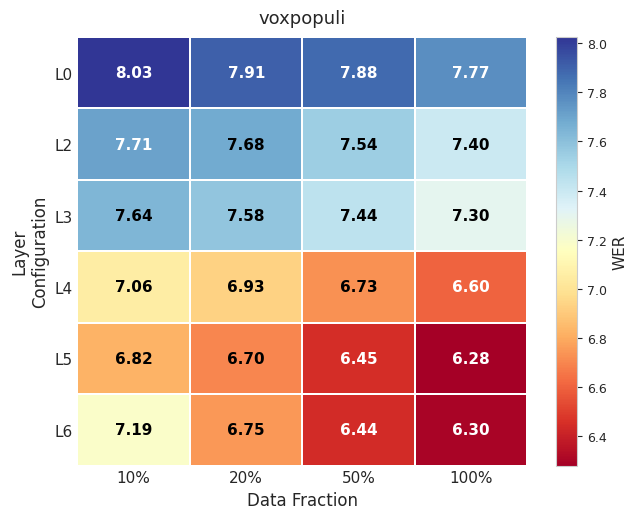

In [59]:


# 2. Path cleaning
df_filtred['result_path'] = df_filtred['result_path'].apply(lambda x: str(x).split("/")[-2])
dataset = "voxpopuli"
df_filtred = df_filtred[df_filtred["dataset"]==dataset]
# 3. Identify the "Best" (min WER) rows per Experiment and Fraction
# We group by both ID and Fraction to find the best run for each specific combo
fractions_of_interest = [1.0, 0.5]

# Split data into the target fractions and everything else
df_target = df_filtred[df_filtred['fraction'].isin(fractions_of_interest)]
df_rest = df_filtred[~df_filtred['fraction'].isin(fractions_of_interest)]

# Find index of minimum WER for target fractions, grouped by experiment and fraction
idx_min = df_target.groupby(["experiment_id", "fraction"])["wer"].idxmin()
df_min = df_target.loc[idx_min]

# 4. Combine and sort
df_best_all = pd.concat([df_min, df_rest], ignore_index=True)

# 5. Final Aggregation
# Included "experiment_id" in the groupby so you get results for every ID
agg_data = df_best_all.groupby(["experiment_id", "label", "fraction"]).aggregate({
    "wer": "mean"
}).reset_index().rename(columns={"label":"layers involved"})

display(agg_data)
plot_wer_heatmap(agg_data,title=dataset)

## Datafraction, WER, Trainable paramters

In [60]:
df_train_params = pd.merge(df,df_deeper_ls_logs,on= "experiment_id", how="left")
df_train_params.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,label,Trainable Parameters,All Parameters,Trainable %
293,0041,voxpopuli,0.2,4.0,NaN,7.507612,0.189524,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.619
294,0041,voxpopuli,0.1,2.0,NaN,7.619180,0.220612,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.619
295,0041,voxpopuli,0.2,0.0,NaN,7.470423,0.190797,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.619
296,0041,voxpopuli,0.1,1.0,NaN,7.572694,0.192562,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.619
297,0041,voxpopuli,0.5,0.0,NaN,7.447179,0.187634,full_dataset_steps,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.619


In [61]:
def plot_param_efficiency_by_fraction(
    df,
    title="WER vs Trainable Parameters by Data Fraction",
    figsize=(8.2, 7),
):
    """
    Plot 4 stacked subplots, one for each data fraction, for one already-filtered dataset.

    Expected columns:
    experiment_id | Trainable % | fraction | wer

    x-axis : Trainable Parameters (%)
    y-axis : WER
    """

    d = df.copy()

    d["fraction"] = pd.to_numeric(d["fraction"], errors="coerce")
    d["wer"] = pd.to_numeric(d["wer"], errors="coerce")
    d["Trainable %"] = pd.to_numeric(d["Trainable %"], errors="coerce")

    d = d.dropna(subset=["fraction", "Trainable %", "wer"]).copy()

    agg = (
        d.groupby(["fraction", "Trainable %"], as_index=False)
        .agg(wer_mean=("wer", "mean"))
    )

    fractions = sorted(agg["fraction"].unique())
    x_order = sorted(agg["Trainable %"].unique())

    x_labels = [f"{x:.2f}%" for x in x_order]
    x_positions = np.arange(len(x_order))
    x_map = dict(zip(x_order, x_positions))

    default_layers = ["L0", "L2", "L3", "L4", "L5", "L6"]
    layer_labels = default_layers[:len(x_order)]

    color_map = {
        0.1: "#d62728",
        0.2: "#1f77b4",
        0.5: "#2ca02c",
        1.0: "#ff7f0e",
    }

    marker_map = {
        0.1: "o",
        0.2: "o",
        0.5: "o",
        1.0: "o",
    }

    y_ranges = []
    for frac in fractions:
        temp = agg[agg["fraction"] == frac]
        r = temp["wer_mean"].max() - temp["wer_mean"].min()
        y_ranges.append(max(r, 0.3))  # minimum to avoid tiny panels

    fig, axes = plt.subplots(
        nrows=len(fractions),
        ncols=1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": y_ranges}
    )

    if len(fractions) == 1:
        axes = [axes]

    for ax, frac in zip(axes, fractions):
        temp = agg[agg["fraction"] == frac].sort_values("Trainable %")

        if temp.empty:
            continue

        x_vals = [x_map[x] for x in temp["Trainable %"]]

        ax.plot(
            x_vals,
            temp["wer_mean"],
            color=color_map.get(frac, "gray"),
            marker=marker_map.get(frac, "o"),
            linewidth=2.3,
            markersize=7,
            alpha=0.95
        )

        # ax.set_ylabel("WER (%)", fontsize=10)
        ax.grid(True, alpha=0.25)
        ax.set_title(f"{int(frac*100)}% data", fontsize=11,fontweight="bold", loc="center", pad=8,)

    axes[-1].set_xticks(x_positions)
    axes[-1].set_xticklabels(x_labels, fontsize=10)

    for xpos, lab in zip(x_positions, layer_labels):
        axes[-1].text(
            xpos,
            -0.25,
            lab,
            transform=axes[-1].get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold"
        )

    axes[-1].set_xlabel("Trainable Parameters", fontsize=11, labelpad=35)

    fig.suptitle(title, fontsize=14, y=0.995)
    fig.supylabel("WER (%)", fontsize=11, x=0.02)
    plt.tight_layout()
    plt.show()

,experiment_id,Trainable %,fraction,wer,layers involved,dataset
0,0023,0.4126,0.1,14.662987,L0,gigaspeech
1,0023,0.4126,0.2,14.964858,L0,gigaspeech
2,0023,0.4126,0.5,13.385887,L0,gigaspeech
3,0023,0.4126,1.0,13.033353,L0,gigaspeech
4,0041,0.6190,0.1,25.171209,L2,gigaspeech
5,0041,0.6190,0.2,13.662984,L2,gigaspeech
6,0041,0.6190,0.5,11.407931,L2,gigaspeech
7,0041,0.6190,1.0,11.092558,L2,gigaspeech
8,0051,0.8246,1.0,10.903285,L3,gigaspeech
9,0061,2.8345,1.0,9.606861,L4,gigaspeech


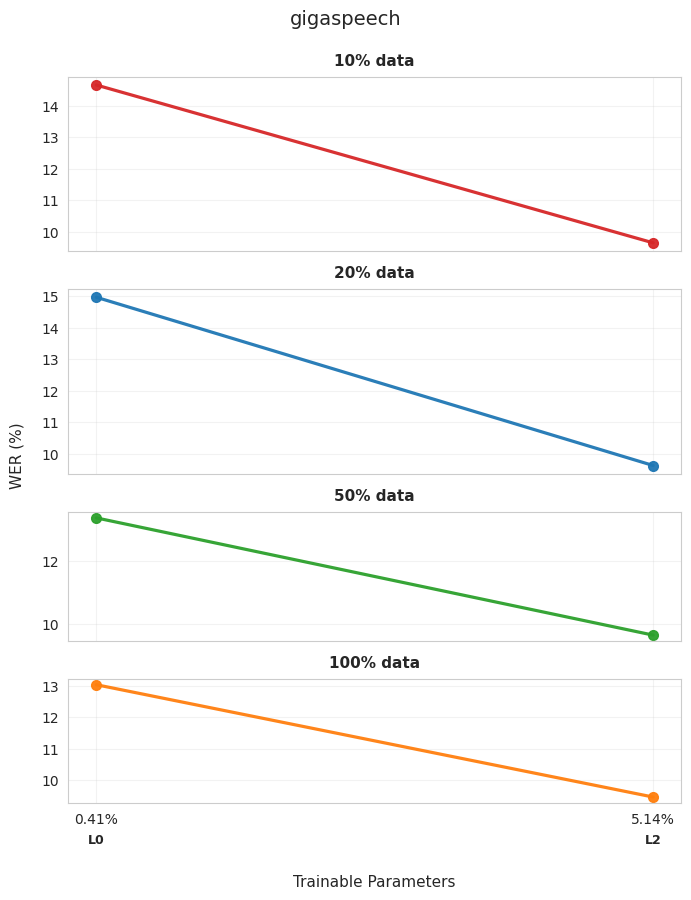

In [62]:
# 1. Broad filter (removed the exp_id and dataset specific filters)
mask = (
    (df_train_params["training_regime"].isin(["data_frac_steps", "1_epoch"]))
    & (df_train_params["exp_type"] == "normal_train_conf")
    & (df_train_params["training_steps"] == "full_steps")
    & (df_train_params["fraction"]!=0.05)
)
df_filtred = df_train_params[mask].copy()


df_filtred['result_path'] = df_filtred['result_path'].apply(lambda x: str(x).split("/")[-2])
dataset = "gigaspeech"
df_filtred = df_filtred[df_filtred["dataset"]==dataset]
# 3. Identify the "Best" (min WER) rows per Experiment and Fraction
# We group by both ID and Fraction to find the best run for each specific combo
fractions_of_interest = [1.0, 0.5]

# Split data into the target fractions and everything else
df_target = df_filtred[df_filtred['fraction'].isin(fractions_of_interest)]
df_rest = df_filtred[~df_filtred['fraction'].isin(fractions_of_interest)]

# Find index of minimum WER for target fractions, grouped by experiment and fraction
idx_min = df_target.groupby(["experiment_id", "fraction"])["wer"].idxmin()
df_min = df_target.loc[idx_min]

# 4. Combine and sort
df_best_all = pd.concat([df_min, df_rest], ignore_index=True)

# 5. Final Aggregation
# Included "experiment_id" in the groupby so you get results for every ID
agg_data = df_best_all.groupby(["experiment_id", "Trainable %", "fraction"]).aggregate({
    "wer": "mean",
    "label":"first",
    "dataset":"first"
}).reset_index().rename(columns={"label":"layers involved"})

display(agg_data)
plot_param_efficiency_by_fraction(agg_data[agg_data["layers involved"].isin(["L0","L5"])],figsize=(7, 9),title=dataset)

In [110]:
def plot_param_efficiency_lines(
    df_filtered,
    datasets=("SPGISpeech 2.0", "VoxPopuli", "GigaSpeech"),
    allowed_fractions=(0.1, 0.2, 0.5, 1.0),
    title="WER vs Trainable Parameters"
):
    """
    Line plot with:
    x-axis = Trainable %
    y-axis = WER
    line   = Data fraction

    Adds labels beneath each x tick:
    L0, L2, L3, L4, L5, L6
    """

    d = df_filtered.copy()

    # -----------------------------
    # Numeric conversion
    # -----------------------------
    d["fraction"] = pd.to_numeric(d["fraction"], errors="coerce")
    d["wer"] = pd.to_numeric(d["wer"], errors="coerce")
    d["Trainable %"] = pd.to_numeric(d["Trainable %"], errors="coerce")

    d = d[d["fraction"].isin(allowed_fractions)].copy()

    # -----------------------------
    # Aggregate
    # -----------------------------
    agg = (
        d.groupby(["dataset", "fraction", "Trainable %"], as_index=False)
        .agg(wer_mean=("wer", "mean"))
    )

    fractions = [f for f in allowed_fractions if f in agg["fraction"].unique()]

    # -----------------------------
    # X-axis values
    # -----------------------------
    x_order = sorted(agg["Trainable %"].dropna().unique())
    x_labels = [f"{x:.2f}%" for x in x_order]
    x_positions = np.arange(len(x_order))
    x_map = dict(zip(x_order, x_positions))

    # Layer labels under ticks
    layer_labels = ["L0", "L2", "L3", "L4", "L5", "L6"]

    # -----------------------------
    # Colors
    # -----------------------------
    color_map = {
        0.1: "#d62728",   # red
        0.2: "#1f77b4",   # blue
        0.5: "#2ca02c",   # green
        1.0: "#ff7f0e",   # orange
    }

    marker_map = {
        0.1: "o",
        0.2: "s",
        0.5: "^",
        1.0: "D",
    }

    # -----------------------------
    # Figure
    # -----------------------------
    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(16, 5.6),
        sharey=True
    )

    if len(datasets) == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):

        sub = agg[agg["dataset"] == ds].copy()

        for frac in fractions:

            temp = sub[sub["fraction"] == frac].sort_values("Trainable %")

            if temp.empty:
                continue

            x_vals = [x_map[x] for x in temp["Trainable %"]]

            ax.plot(
                x_vals,
                temp["wer_mean"],
                color=color_map[frac],
                marker=marker_map[frac],
                linewidth=2.2,
                markersize=6.5,
                label=f"{int(frac*100)}%"
            )

        # Main ticks
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=10)

        # Add second label below ticks
        for xpos, lab in zip(x_positions, layer_labels):
            ax.text(
                xpos,
                -0.10,
                lab,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=9,
                fontweight="bold"
            )

        ax.invert_yaxis()

        ax.set_title(ds, fontsize=12, pad=10)
        ax.set_xlabel("Trainable Parameters", fontsize=11, labelpad=35)

        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("WER", fontsize=11)

    # Shared legend
    handles, labels = axes[-1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Data Fraction",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=len(fractions),
        frameon=False
    )

    fig.suptitle(title, fontsize=14, y=1.08)

    plt.tight_layout()
    plt.show()

In [114]:
df_filtred[(df_filtred["dataset"]=="voxpopuli")&((df_filtred["fraction"]==1.0))].sort_values("label")

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,label,Trainable Parameters,All Parameters,Trainable %
5,0023,voxpopuli,1.0,0.0,123,7.767938,0.199934,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/seed_123_frac_1....,BU,L0,3384896,820352576,0.4126
6,0023,voxpopuli,1.0,0.0,123456,7.902750,0.211493,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/seed_123456_frac...,BU,L0,3384896,820352576,0.4126
7,0023,voxpopuli,1.0,0.0,12345,7.956209,0.215703,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/seed_12345_frac_...,BU,L0,3384896,820352576,0.4126
8,0023,voxpopuli,1.0,0.0,1234,7.888804,0.209933,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/seed_1234_frac_1...,BU,L0,3384896,820352576,0.4126
9,0023,voxpopuli,1.0,0.0,42,7.849290,0.211748,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/seed_42_frac_1.0...,BU,L0,3384896,820352576,0.4126
236,0023,voxpopuli,1.0,0.0,NaN,7.863236,0.210525,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/data_scaling/dat...,Rad1,L0,3384896,820352576,0.4126
234,0023,voxpopuli,1.0,0.0,NaN,7.951561,NaN,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/002/0023/data_scaling/dat...,Rad1,L0,3384896,820352576,0.4126
291,0041,voxpopuli,1.0,0.0,NaN,7.416963,0.190130,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling/dat...,Rad1,L2,5088832,822056512,0.6190
1,0041,voxpopuli,1.0,0.0,None,7.398368,0.186027,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/0041_frac_1.0_su...,BU,L2,5088832,822056512,0.6190
290,0041,voxpopuli,1.0,0.0,NaN,7.398368,0.186027,1_epoch,full_steps,normal_train_conf,../outputs/voxpopuli/004/0041/data_scaling_fra...,Rad1,L2,5088832,822056512,0.6190


In [106]:
df_regime_compare = df.copy()
mask = ((df["exp_type"] == "normal_train_conf")
    & (df["training_steps"] == "full_steps")
)
df_regime_filtered = df_regime_compare[mask]
selected_layers = ["L2","L5","L7"]
dataset = "spgispeech_2"
df_plot = df_regime_filtered[(df_regime_filtered["dataset"]==dataset)&(df_regime_filtered["label"].isin(selected_layers))]
df_plot.tail()

,experiment_id,dataset,fraction,subset,seed,wer,wer_accent,training_regime,training_steps,exp_type,result_path,source,label
188,0041,spgispeech_2,0.1,2.0,None,7.146072,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling_...,BU,L2
189,0041,spgispeech_2,0.2,1.0,None,7.148416,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling_...,BU,L2
190,0041,spgispeech_2,0.5,1.0,None,6.691546,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling_...,BU,L2
191,0041,spgispeech_2,0.1,0.0,None,7.349308,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling_...,BU,L2
192,0041,spgispeech_2,0.2,0.0,None,7.359153,NaN,data_frac_steps,full_steps,normal_train_conf,../outputs/spgispeech_2/004/0041/data_scaling_...,BU,L2


In [107]:
def plot_grid_dataset_layer(
    df,
    datasets=("spgispeech_2", "voxpopuli", "gigaspeech"),
    layers=("L0", "L5"),
    fraction_order=(0.1, 0.2, 0.5, 1.0),
    figsize=(14, 6),
):
    """
    2x3 grid:
        rows = layers
        cols = datasets

    Each subplot:
        - 2 lines: Data-Limited vs Fixed-Budget
    """

    df_plot = df.copy()
    df_plot["fraction"] = df_plot["fraction"].astype(float)

    # --- Aggregate duplicates ---
    df_plot = (
        df_plot.groupby(
            ["dataset", "label", "training_regime", "fraction"],
            as_index=False
        )["wer"]
        .mean()
    )

    # --- Handle 1_epoch (shared endpoint) ---
    df_epoch = df_plot[df_plot["training_regime"] == "1_epoch"].copy()

    df_epoch_dl = df_epoch.copy()
    df_epoch_dl["training_regime"] = "data_frac_steps"

    df_epoch_fb = df_epoch.copy()
    df_epoch_fb["training_regime"] = "full_dataset_steps"

    df_plot = pd.concat(
        [
            df_plot[df_plot["training_regime"] != "1_epoch"],
            df_epoch_dl,
            df_epoch_fb,
        ],
        ignore_index=True,
    )

    df_plot = df_plot.drop_duplicates(
        subset=["dataset", "label", "training_regime", "fraction"],
        keep="last"
    )

    # --- Plot ---
    fig, axes = plt.subplots(
        len(layers), len(datasets),
        figsize=figsize,
        sharex=True,
        sharey=False
    )

    regime_styles = {
        "data_frac_steps": "-",
        "full_dataset_steps": "--",
    }

    regime_labels = {
        "data_frac_steps": "Data-Limited",
        "full_dataset_steps": "Fixed-Budget",
    }

    for i, layer in enumerate(layers):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j] if len(layers) > 1 else axes[j]

            df_sub = df_plot[
                (df_plot["label"] == layer) &
                (df_plot["dataset"] == dataset)
            ]

            for regime in ("data_frac_steps", "full_dataset_steps"):
                cur = df_sub[df_sub["training_regime"] == regime]

                if cur.empty:
                    continue

                cur = (
                    cur.set_index("fraction")
                    .reindex(fraction_order)
                    .reset_index()
                )

                ax.plot(
                    cur["fraction"],
                    cur["wer"],
                    marker="o",
                    linestyle=regime_styles[regime],
                    linewidth=2,
                    label=regime_labels[regime]
                )

            ax.set_title(layer, fontsize=12,fontweight="bold")


            ax.set_xticks(fraction_order)
            ax.set_xticklabels([f"{int(x*100)}%" for x in fraction_order], fontsize=11)
            ax.grid(True)

    # Shared legend (only once)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True,bbox_to_anchor=(0.5, -0.10),fontsize=13)

    dataset_names = ["(a) SPGISpeech2", "(b) VoxPopuli", "(c) GigaSpeech"]

    for j, name in enumerate(dataset_names):
        fig.text(
            x=(j + 0.5) / len(dataset_names),  # center under each column
            y=0.02,                            # vertical position (adjust if needed)
            s=name,
            ha="center",
            fontsize=14
        )
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.subplots_adjust(hspace=0.25)
    plt.show()

In [108]:
df_regime_2_plot = df_regime_filtered[df_regime_filtered["label"].isin(["L0", "L5"])]

fractions_of_interest = [1.0, 0.5]

# Split data into the target fractions and everything else
df_target = df_regime_2_plot[df_regime_2_plot['fraction'].isin(fractions_of_interest)]
df_rest = df_regime_2_plot[~df_regime_2_plot['fraction'].isin(fractions_of_interest)]

# Find index of minimum WER for target fractions, grouped by experiment and fraction
idx_min = df_target.groupby(["dataset","training_regime","experiment_id", "fraction"])["wer"].idxmin()
df_min = df_target.loc[idx_min]

# 4. Combine and sort
df_best_all = pd.concat([df_min, df_rest], ignore_index=True)

# 5. Final Aggregation
# Included "experiment_id" in the groupby so you get results for every ID
agg_data = df_best_all.groupby(["dataset","training_regime","experiment_id", "label", "fraction"]).aggregate({
    "wer": "mean"
}).reset_index()

display(agg_data)

,dataset,training_regime,experiment_id,label,fraction,wer
0,gigaspeech,1_epoch,0023,L0,1.00,13.033353
1,gigaspeech,1_epoch,0071,L5,1.00,9.463915
2,gigaspeech,data_frac_steps,0023,L0,0.10,14.662987
3,gigaspeech,data_frac_steps,0023,L0,0.20,14.964858
4,gigaspeech,data_frac_steps,0023,L0,0.50,13.385887
5,gigaspeech,data_frac_steps,0071,L5,0.10,9.647408
6,gigaspeech,data_frac_steps,0071,L5,0.20,9.618877
7,gigaspeech,data_frac_steps,0071,L5,0.50,9.660373
8,gigaspeech,full_dataset_steps,0023,L0,0.10,16.016721
9,gigaspeech,full_dataset_steps,0023,L0,0.20,14.266107


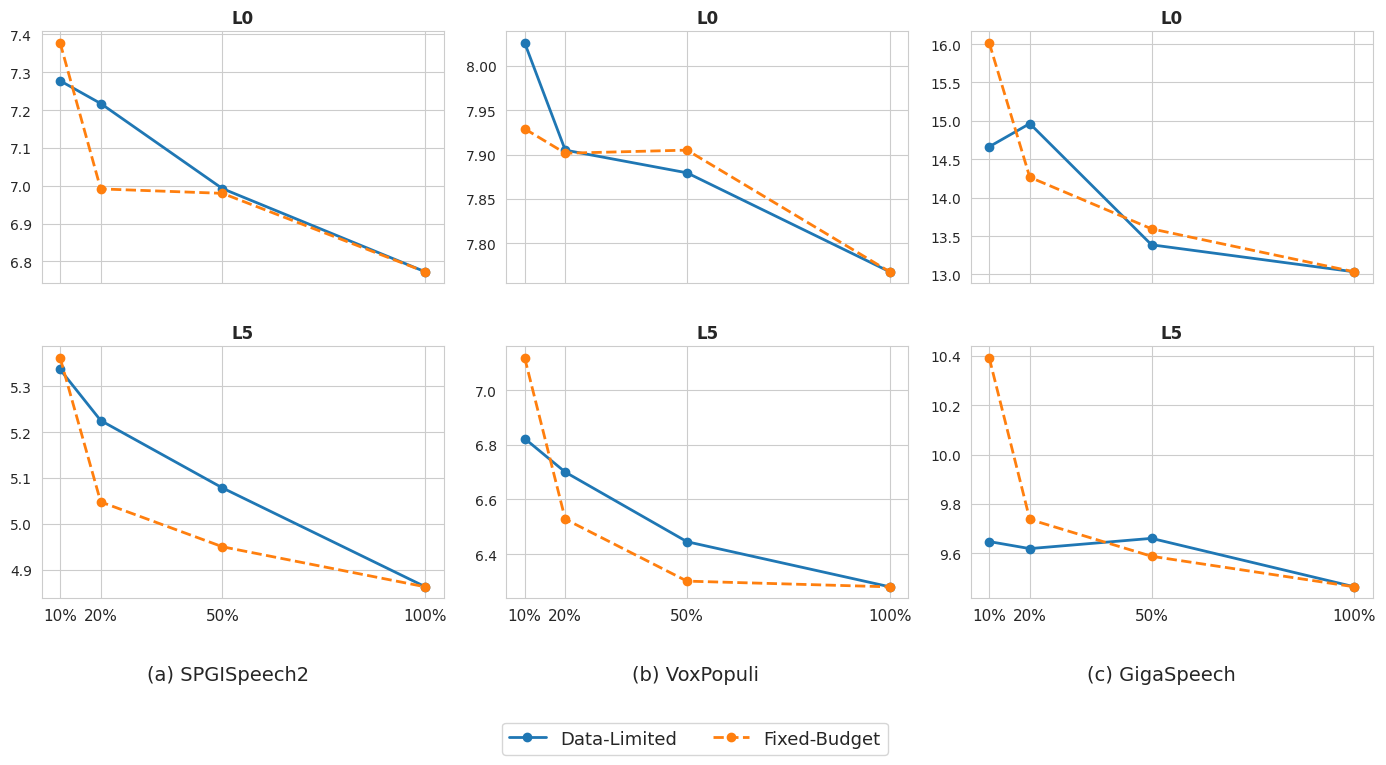

In [109]:
plot_grid_dataset_layer(df=agg_data,
    layers=("L0", "L5"),figsize=(14,7))

In [110]:
df_final[(df_final["dataset"]=="spgispeech_2")&(df_final["label"]=="L0")]

NameError: name 'df_final' is not defined

In [ ]:
selected_layers = ['L0', 'L4', 'L5']  # main plot layers
datasets = sorted(df['dataset'].unique())

# Ensure correct ordering of fractions
fraction_order = [0.1, 0.2, 0.5, 1.0]

df_plot = (
    df_final[df_final['label'].isin(selected_layers)]
    .groupby(['dataset', 'label', 'fraction'])['wer']
    .mean()
    .reset_index()
)
df_plot.head()

,dataset,label,fraction,wer
0,gigaspeech,L0,0.1,14.641351
1,gigaspeech,L0,0.2,14.266107
2,gigaspeech,L0,0.5,13.385887
3,gigaspeech,L0,1.0,13.449742
4,gigaspeech,L4,1.0,9.674371


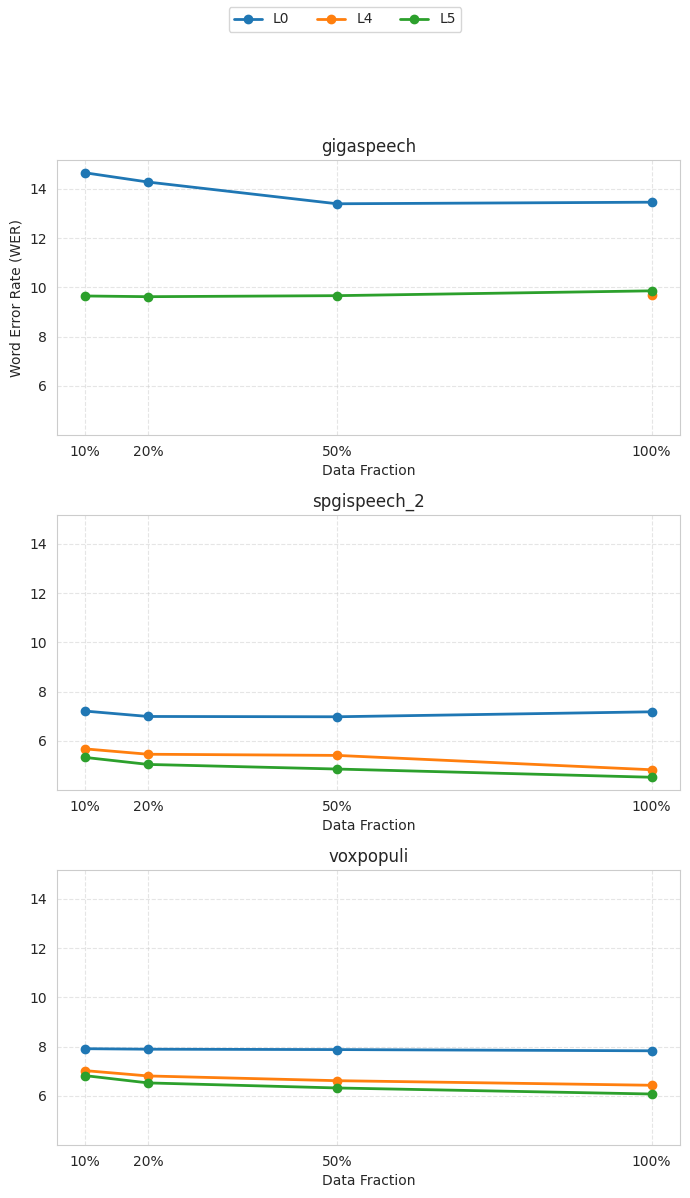

In [ ]:
fig, axes = plt.subplots(len(datasets),1, figsize=(7, 12), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    data_ds = df_plot[df_plot['dataset'] == dataset]

    for layer in selected_layers:
        data_layer = data_ds[data_ds['label'] == layer]

        # Ensure correct order of x-axis
        data_layer = data_layer.set_index('fraction').reindex(fraction_order).reset_index()

        ax.plot(
            data_layer['fraction'],
            data_layer['wer'],
            marker='o',
            linewidth=2,
            label=layer
        )

    ax.set_title(dataset)
    ax.set_xlabel("Data Fraction")
    ax.set_xticks(fraction_order)
    ax.set_xticklabels(['10%', '20%', '50%', '100%'])
    ax.grid(True, linestyle='--', alpha=0.5)

# Shared Y label
axes[0].set_ylabel("Word Error Rate (WER)")

# Legend (single, clean)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
lora_agg, base_001_df= prepare_data(df_final,"gigaspeech")
plot_wer_experiments(df_final,"gigaspeech")


NameError: name 'prepare_data' is not defined

## Investigating optimisation steps discripancy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re
import seaborn as sns

In [ ]:
def parse_asr_results(file_path):
    path = Path(file_path)
    
    with open(path, 'r') as f:
        data = json.load(f)
    
    # Improved WER extraction
    metrics = data.get("metrics", {})
    wer = None
    
    if metrics:
        # Get the first value in the metrics dict (e.g., 'speechcolab-gigaspeech-m')
        first_val = list(metrics.values())[0]
        
        # If the value is a dict, get 'wer' from it. 
        # If it's already a float (unlikely based on your example, but safe), use it.
        if isinstance(first_val, dict):
            wer = first_val.get("wer")
        else:
            wer = first_val

    path_str = str(path)
    
    # Updated Regex to handle the new path format you provided: 
    # .../0041/0041_frac_1.0_subset_0_old/results.json
    
    # 1. Dataset Name
    dataset_name = "gigaspeech" if "gigaspeech" in path_str else ("spgispeech_2" if "spgispeech_2" in path_str else "voxpopuli")
    
    # 2. Experiment ID - Look for the 4 digits after a slash
    exp_id_match = re.search(r'/(\d{4})/', path_str)
    exp_id = exp_id_match.group(1) if exp_id_match else None
    
    # 3. Data Fraction - Handles both 'frac_0.1' and 'frac_1.0'
    frac_match = re.search(r'frac_([\d.]+)', path_str)
    data_fraction = float(frac_match.group(1)) if frac_match else None
    
    # 4. Training Logic
    is_old = "_old" in path_str
    training_regime = "data_frac_steps" if is_old else "full_dataset_steps"

    return {
        "dataset": dataset_name,
        "experiment_id": exp_id,
        "data_fraction": data_fraction,
        "wer": wer,
        "is_old_regime": is_old,
        "training_logic": training_regime
    }

In [ ]:
seletced_paths = "/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081"
all_res_paths = list(Path(seletced_paths).rglob("results.json"))
exclude_list = ["0.05", "half", "123_","1234_", "123456_", "42_"]
all_res_paths = [
    path for path in all_res_paths 
    if not any(exclude in str(path) for exclude in exclude_list)
]
all_res_paths

[PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/0081_frac_1.0_subset_0_old/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_2/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.5_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.2_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.5_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/008/0081/data_scaling/data_scaling_frac_0.1_subset_0/results.json'),
 PosixPath('/mnt/asr-data

In [ ]:
all_res = []
for p in all_res_paths:
    res = parse_asr_results(str(p))
    all_res.append(res)

In [ ]:
df = pd.DataFrame(all_res).sort_values(["training_logic","data_fraction"])
mask = df['data_fraction'] == 1.0

# 2. Get the valid WER (filtering out 'False' or boolean noise)
# We convert to numeric so we can safely find the minimum
valid_wer = pd.to_numeric(df.loc[mask, 'wer'], errors='coerce').min()

# 3. Update both 'wer' and 'is_old_regime' to this value for those rows
df.loc[mask, ['wer', 'is_old_regime']] = valid_wer
df

/tmp/ipykernel_1063953/2291529175.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0487203389166659' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[mask, ['wer', 'is_old_regime']] = valid_wer


,dataset,experiment_id,data_fraction,wer,is_old_regime,training_logic
9,spgispeech_2,0081,0.1,0.051836,True,data_frac_steps
10,spgispeech_2,0081,0.1,0.054149,True,data_frac_steps
13,spgispeech_2,0081,0.1,0.052726,True,data_frac_steps
11,spgispeech_2,0081,0.2,0.052208,True,data_frac_steps
14,spgispeech_2,0081,0.2,0.053167,True,data_frac_steps
12,spgispeech_2,0081,0.5,0.051583,True,data_frac_steps
0,spgispeech_2,0081,1.0,0.048720,0.04872,data_frac_steps
1,spgispeech_2,0081,0.1,0.083069,False,full_dataset_steps
2,spgispeech_2,0081,0.1,0.082265,False,full_dataset_steps
7,spgispeech_2,0081,0.1,0.081039,False,full_dataset_steps


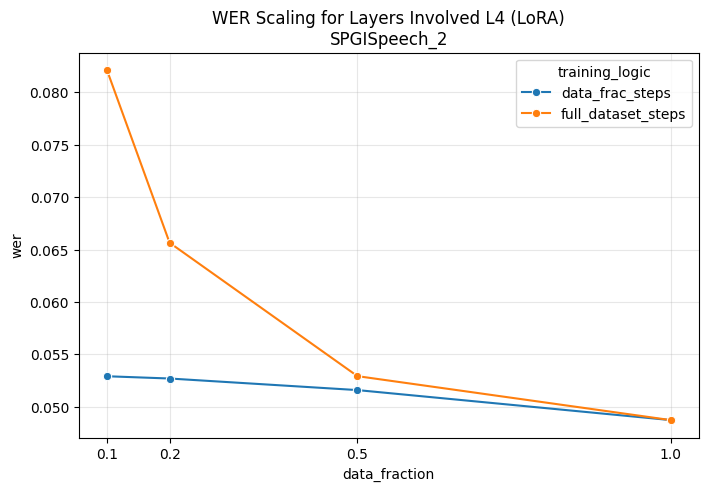

In [ ]:
unique_fractions = sorted(df['data_fraction'].unique())
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='data_fraction', y='wer', hue='training_logic', marker='o',errorbar=None)

# Force the x-axis to only show these specific "distinct" numbers
plt.xticks(unique_fractions)

plt.title("WER Scaling for Layers Involved L4 (LoRA)\nSPGISpeech_2")
plt.grid(alpha=0.3)
plt.show()